## 1. Import libraries and simulation data

### 1.1 Libraries

In [45]:
import os
import time
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

### 1.2 Load simulation files

In [2]:
# Keyword mapping: if any keyword appears in the filename, use the standard name
FILE_NAME_MAP = {
    "oxygen_concentration": ["oxygen", "o2", "concentration", "conc"],
    "pressure":             ["pressure", "pres", "press"],
    "velocity_field":       ["velocity", "vel", "speed", "flow"],
}

def standardize_name(file_stem: str) -> str:
    """Return the standard data type name for a given filename stem, or None if unrecognized."""
    lower = file_stem.lower()
    for standard_name, keywords in FILE_NAME_MAP.items():
        if any(kw in lower for kw in keywords):
            return standard_name
    return None  # Unrecognized file


def find_data_start(file_path: str, sep=",") -> int:
    """
    Skips metadata by finding the first line with the maximum field count.
    Works even when metadata lines outnumber data lines.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()
    
    field_counts = [len(line.split(sep)) for line in lines if line.strip()]
    max_count = max(field_counts)
    
    for i, line in enumerate(lines):
        if len(line.split(sep)) == max_count:
            return i  # This is your header row
    
    return 0


def load_csv_smart(file_path: str) -> pd.DataFrame:
    skip = find_data_start(file_path)
    if skip > 0:
        print(f"    ↳ Skipping {skip} metadata line(s)")
    return pd.read_csv(file_path, skiprows=skip)


# Dictionary to store all dataframes, keyed by (folder_name, file_stem)
dataframes = {}

# Base directory containing all simulation folders
base_dir = "simulation-data"

# Iterate through all subdirectories
for folder_name in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.isdir(folder_path):
        continue  # Skip any stray files
    
    for csv_file in sorted(os.listdir(folder_path)):
        if not csv_file.endswith(".csv"):
            continue

        file_stem = os.path.splitext(csv_file)[0]
        standard_name = standardize_name(file_stem)

        if standard_name is None:
            print(f"  ⚠ Skipped unrecognized file: {folder_name} / {csv_file}")
            continue

        key = (folder_name, standard_name)

        if key in dataframes:
            print(f"  ⚠ Duplicate detected for {key} — already loaded, skipping {csv_file}")
            continue

        file_path = os.path.join(folder_path, csv_file)
        dataframes[key] = load_csv_smart(file_path)
        print(f"Loaded: {folder_name} / {csv_file}  →  '{standard_name}'")
        

# Access example:
# dataframes[("020concentration", "species")]

Loaded: 020concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 020concentration / Pressure.csv  →  'pressure'
Loaded: 020concentration / Velocity_field.csv  →  'velocity_field'
Loaded: 021concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 021concentration / Pressure.csv  →  'pressure'
Loaded: 021concentration / Velocity.csv  →  'velocity_field'
Loaded: 022concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 022concentration / Pressure.csv  →  'pressure'
Loaded: 022concentration / Velocity.csv  →  'velocity_field'
    ↳ Skipping 8 metadata line(s)
Loaded: 023concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 023concentration / Pressure.csv  →  'pressure'
Loaded: 023concentration / Velocity.csv  →  'velocity_field'
    ↳ Skipping 8 metadata line(s)
Loaded: 024concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 024concentration / Pressure.csv  →  'pressure'
Loaded: 024c

In [3]:
file_path = 'simulation-data/023concentration/Oxygen_concentration.csv'

with open(file_path, "r") as f:
    for i, line in enumerate(f):
        print(repr(line))  # repr() shows \t, \n etc. clearly
        if i >= 10:
            break

'% Model,TP423.mph\n'
'% Version,COMSOL 6.3.0.420\n'
'% Date,"Mar 22 2026, 16:13"\n'
'% Dimension,2\n'
'% Nodes,1\n'
'% Expressions,1060\n'
'% Description,"Molar concentration, c"\n'
'% Length unit,m\n'
'% x,y,c (mol/m^3) @ t=0,c (mol/m^3) @ t=0.001,c (mol/m^3) @ t=0.002,c (mol/m^3) @ t=0.003,c (mol/m^3) @ t=0.004,c (mol/m^3) @ t=0.005,c (mol/m^3) @ t=0.006,c (mol/m^3) @ t=0.007,c (mol/m^3) @ t=0.008,c (mol/m^3) @ t=0.009,c (mol/m^3) @ t=0.01,c (mol/m^3) @ t=0.011,c (mol/m^3) @ t=0.012,c (mol/m^3) @ t=0.013,c (mol/m^3) @ t=0.014,c (mol/m^3) @ t=0.015,c (mol/m^3) @ t=0.016,c (mol/m^3) @ t=0.017,c (mol/m^3) @ t=0.018,c (mol/m^3) @ t=0.019,c (mol/m^3) @ t=0.02,c (mol/m^3) @ t=0.021,c (mol/m^3) @ t=0.022,c (mol/m^3) @ t=0.023,c (mol/m^3) @ t=0.024,c (mol/m^3) @ t=0.025,c (mol/m^3) @ t=0.026,c (mol/m^3) @ t=0.027,c (mol/m^3) @ t=0.028,c (mol/m^3) @ t=0.029,c (mol/m^3) @ t=0.03,c (mol/m^3) @ t=0.031,c (mol/m^3) @ t=0.032,c (mol/m^3) @ t=0.033,c (mol/m^3) @ t=0.034,c (mol/m^3) @ t=0.035,c (mo

In [4]:
# List all loaded dataframes
for (folder, file), df in dataframes.items():
    print(f"{folder} / {file}: {df.shape}")

020concentration / oxygen_concentration: (1, 1102)
020concentration / pressure: (4203, 1102)
020concentration / velocity_field: (4203, 1102)
021concentration / oxygen_concentration: (1, 1062)
021concentration / pressure: (4203, 1062)
021concentration / velocity_field: (4203, 1062)
022concentration / oxygen_concentration: (1, 1062)
022concentration / pressure: (4203, 1062)
022concentration / velocity_field: (4203, 1062)
023concentration / oxygen_concentration: (1, 1062)
023concentration / pressure: (4203, 1062)
023concentration / velocity_field: (4203, 1062)
024concentration / oxygen_concentration: (1, 1062)
024concentration / pressure: (4203, 1062)
024concentration / velocity_field: (4203, 1062)
025concentration / oxygen_concentration: (1, 1102)
025concentration / pressure: (4203, 1102)
025concentration / velocity_field: (4203, 1102)
026concentration / oxygen_concentration: (1, 1062)
026concentration / pressure: (4203, 1062)
026concentration / velocity_field: (4203, 1062)
027concentrat

### 1.3 Access specific dataframe to check

In [5]:
# Access a specific one
sim_access = "030concentration"

dfoc = dataframes[(sim_access, "oxygen_concentration")]
dfpr = dataframes[(sim_access, "pressure")]
dfvf = dataframes[(sim_access, "velocity_field")]

dfpr

,x,y,p (Pa) @ t=0,p (Pa) @ t=0.001,p (Pa) @ t=0.002,p (Pa) @ t=0.003,p (Pa) @ t=0.004,p (Pa) @ t=0.005,p (Pa) @ t=0.006,p (Pa) @ t=0.007,...,Unnamed: 1092,Unnamed: 1093,Unnamed: 1094,Unnamed: 1095,Unnamed: 1096,Unnamed: 1097,Unnamed: 1098,Unnamed: 1099,Unnamed: 1100,Unnamed: 1101
0,0.011901,-0.002131,0.000302,0.000294,0.000477,0.000441,0.000485,0.000478,0.000487,0.000489,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.012000,-0.002072,0.000467,0.001275,0.001087,0.001114,0.001108,0.001106,0.001103,0.001104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.011846,-0.002072,0.000530,0.000176,0.000423,0.000377,0.000416,0.000413,0.000420,0.000423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.012000,-0.002140,0.000111,0.000457,0.000600,0.000591,0.000626,0.000630,0.000636,0.000641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.011862,-0.003872,0.000450,0.000133,0.000390,0.000335,0.000383,0.000373,0.000383,0.000383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4198,-0.011382,0.000098,0.022281,-0.000314,0.007710,0.003939,0.005249,0.004045,0.004414,0.004091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4199,-0.011525,0.000023,0.022284,-0.000315,0.007712,0.003939,0.005250,0.004045,0.004414,0.004091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4200,-0.011533,0.000055,0.022284,-0.000315,0.007711,0.003939,0.005250,0.004045,0.004414,0.004091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4201,-0.011682,-0.000008,0.022287,-0.000316,0.007712,0.003939,0.005250,0.004045,0.004414,0.004092,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Check dataframe sizes

In [6]:
from collections import defaultdict

# Group shapes by file type
shapes_by_type = defaultdict(dict)
for (folder, file_type), df in dataframes.items():
    shapes_by_type[file_type][folder] = df.shape

# Check consistency and report
all_ok = True
for file_type, folder_shapes in shapes_by_type.items():
    shapes = set(folder_shapes.values())
    
    if len(shapes) == 1:
        print(f"✓ {file_type}: all folders agree on shape {shapes.pop()}")
    else:
        all_ok = False
        print(f"✗ {file_type}: INCONSISTENT SHAPES")
        for folder, shape in folder_shapes.items():
            print(f"    {folder}: {shape}")

if all_ok:
    print("\nAll files are consistent.")
else:
    print("\nWarning: some files have mismatched dimensions — check the folders above.")

✗ oxygen_concentration: INCONSISTENT SHAPES
    020concentration: (1, 1102)
    021concentration: (1, 1062)
    022concentration: (1, 1062)
    023concentration: (1, 1062)
    024concentration: (1, 1062)
    025concentration: (1, 1102)
    026concentration: (1, 1062)
    027concentration: (1, 1062)
    028concentration: (1, 1062)
    029concentration: (1, 1062)
    030concentration: (1, 1102)
✗ pressure: INCONSISTENT SHAPES
    020concentration: (4203, 1102)
    021concentration: (4203, 1062)
    022concentration: (4203, 1062)
    023concentration: (4203, 1062)
    024concentration: (4203, 1062)
    025concentration: (4203, 1102)
    026concentration: (4203, 1062)
    027concentration: (4203, 1062)
    028concentration: (4203, 1062)
    029concentration: (4203, 1062)
    030concentration: (4203, 1102)
✗ velocity_field: INCONSISTENT SHAPES
    020concentration: (4203, 1102)
    021concentration: (4203, 1062)
    022concentration: (4203, 1062)
    023concentration: (4203, 1062)
    024co

### 1.5 Standardize dataframe size

In [7]:
def truncate_dataframes(dataframes: dict, expected_shape: dict) -> dict:
    """
    Truncates dataframes to the expected shape per file type.
    
    Args:
        dataframes: dict keyed by (folder_name, file_type)
        expected_shape: dict keyed by file_type, values are (rows, cols)
                        use None on either axis to skip truncation on that axis
    Returns:
        New dict with truncated dataframes.
    """
    truncated = {}
    all_ok = True

    for (folder, file_type), df in dataframes.items():
        target = expected_shape.get(file_type)

        if target is None:
            truncated[(folder, file_type)] = df
            continue

        target_rows, target_cols = target
        original_shape = df.shape

        if target_rows is not None:
            df = df.iloc[:target_rows, :]
        if target_cols is not None:
            df = df.iloc[:, :target_cols]

        if df.shape != original_shape:
            all_ok = False
            print(f"  ✂ Truncated {folder}/{file_type}: {original_shape} → {df.shape}")

        truncated[(folder, file_type)] = df

    if all_ok:
        print("✓ No truncation needed — all shapes already consistent.")
    else:
        print("\n✓ Truncation complete.")

    return truncated

In [8]:
EXPECTED_SHAPE = {
    "oxygen_concentration": (None, 1062),
    "pressure":             (4203, 1062),
    "velocity_field":       (4203, 1062),
}

dataframes_trunc = truncate_dataframes(dataframes, EXPECTED_SHAPE)

  ✂ Truncated 020concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 020concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 020concentration/velocity_field: (4203, 1102) → (4203, 1062)
  ✂ Truncated 025concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 025concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 025concentration/velocity_field: (4203, 1102) → (4203, 1062)
  ✂ Truncated 030concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 030concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 030concentration/velocity_field: (4203, 1102) → (4203, 1062)

✓ Truncation complete.


### 1.6 Visualize pressure field and find get inlet coordinate

In [9]:
# Access a specific simulation data
sim_access = "027concentration"

dfoc = dataframes_trunc[(sim_access, "oxygen_concentration")]
dfpr = dataframes_trunc[(sim_access, "pressure")]
dfvf = dataframes_trunc[(sim_access, "velocity_field")]

dfpr

,% x,y,p (Pa) @ t=0,p (Pa) @ t=0.001,p (Pa) @ t=0.002,p (Pa) @ t=0.003,p (Pa) @ t=0.004,p (Pa) @ t=0.005,p (Pa) @ t=0.006,p (Pa) @ t=0.007,...,p (Pa) @ t=3.55,p (Pa) @ t=3.6,p (Pa) @ t=3.65,p (Pa) @ t=3.7,p (Pa) @ t=3.75,p (Pa) @ t=3.8,p (Pa) @ t=3.85,p (Pa) @ t=3.9,p (Pa) @ t=3.95,p (Pa) @ t=4
0,0.011901,-0.002131,0.000357,0.000352,0.000411,0.000466,0.000472,0.000480,0.000487,0.000488,...,0.001684,0.001684,0.001684,0.001684,0.001684,0.001684,0.001684,0.001684,0.001684,0.001685
1,0.012000,-0.002072,0.000347,0.001132,0.001119,0.001105,0.001113,0.001102,0.001106,0.001102,...,0.003940,0.003941,0.003941,0.003941,0.003941,0.003941,0.003941,0.003941,0.003942,0.003942
2,0.011846,-0.002072,0.000621,0.000289,0.000357,0.000394,0.000411,0.000411,0.000423,0.000420,...,0.001419,0.001419,0.001419,0.001419,0.001419,0.001419,0.001419,0.001419,0.001419,0.001419
3,0.012000,-0.002140,0.000112,0.000456,0.000554,0.000603,0.000621,0.000629,0.000637,0.000640,...,0.002271,0.002271,0.002271,0.002271,0.002271,0.002271,0.002271,0.002272,0.002272,0.002272
4,0.011862,-0.003872,0.000559,0.000250,0.000304,0.000369,0.000364,0.000379,0.000380,0.000384,...,0.001275,0.001275,0.001275,0.001275,0.001275,0.001275,0.001275,0.001275,0.001275,0.001275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4198,-0.011382,0.000098,0.028046,0.005430,0.003858,0.005909,0.004015,0.004676,0.004106,0.004254,...,0.016491,0.016491,0.016492,0.016493,0.016493,0.016494,0.016495,0.016496,0.016497,0.016497
4199,-0.011525,0.000023,0.028050,0.005430,0.003857,0.005910,0.004015,0.004676,0.004107,0.004254,...,0.016741,0.016741,0.016742,0.016743,0.016744,0.016744,0.016745,0.016746,0.016747,0.016748
4200,-0.011533,0.000055,0.028050,0.005430,0.003857,0.005910,0.004015,0.004676,0.004107,0.004254,...,0.016716,0.016716,0.016717,0.016718,0.016718,0.016719,0.016720,0.016721,0.016722,0.016722
4201,-0.011682,-0.000008,0.028055,0.005431,0.003857,0.005911,0.004015,0.004677,0.004107,0.004254,...,0.017699,0.017700,0.017700,0.017701,0.017702,0.017703,0.017704,0.017704,0.017705,0.017706


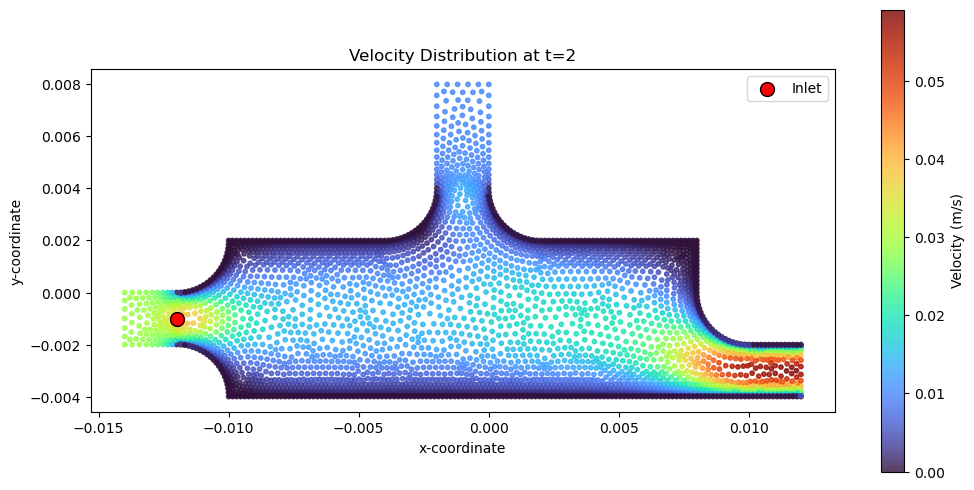

In [10]:
# Creating copy of dataset for analysis

sim_to_check = "velocity"
sim_time = "2"

def plot_engine(sim_to_check, sim_time):
    if sim_to_check == "velocity":
        df_engine_plot = dfvf.copy()
        time_col = f"spf.U (m/s) @ t={sim_time}"
        label_name = "Velocity (m/s)"
    elif sim_to_check == "pressure":
        df_engine_plot = dfpr.copy()
        time_col = f"p (Pa) @ t={sim_time}"
        label_name = "Pressure (Pa)"
    else:
        print("Invalid simulation type.")
        return
    
    # 2. Check if column actually exists to avoid KeyError
    if time_col not in df_engine_plot.columns:
        print(f"Error: Column '{time_col}' not found in dataframe.")
        return

    # Select the column for t= sim_time
    time_col_index = df_engine_plot.columns.get_loc(time_col)

    # Use iloc to select coordinates and the specific data column
    plot_data = df_engine_plot.iloc[:, [0, 1, time_col_index]].copy()
    plot_data.columns = ["x", "y", "value"]

    # Find inlet coordinates (max pressure)
    # max_pressure_idx = pressure_data["pressure"].idxmax()
    inlet_x = -0.012
    inlet_y = -0.001

    # Plotting
    plt.figure(figsize=(12, 6))
    sc = plt.scatter(
        plot_data["x"],
        plot_data["y"],
        c=plot_data["value"],
        cmap="turbo",
        s=10,
        alpha=0.8
    )

    # 3. Dynamic labels based on what we are plotting
    plt.colorbar(sc, label=label_name)
    plt.title(f"{sim_to_check.capitalize()} Distribution at t={sim_time}")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.gca().set_aspect("equal", adjustable="box")

    # Highlight the inlet as a big red dot
    plt.scatter(
        inlet_x,
        inlet_y,
        c="red",
        s=100,  # Bigger size
        edgecolor="black",  # Optional: add a black border
        linewidth=1,  # Optional: border width
        label="Inlet",  # Optional: add a legend entry
    )

    # Optional: Add a legend
    plt.legend()

    plt.show()

plot_engine(sim_to_check, sim_time)

In [11]:
# Find inlet coordinates

# 1. Define the specific time column you want to analyze
target_time = 'p (Pa) @ t=2' 

# 2. Find the row index where the pressure is highest in that column
row_idx = dfpr[target_time].idxmax()

# 3. Extract the x and y coordinates from that same row index
# Note: Based on your snippet, the first column is '% x' and the second is 'y'
max_x = dfpr.loc[row_idx, '% x']
max_y = dfpr.loc[row_idx, 'y']
max_val = dfpr.loc[row_idx, target_time]

print(f"--- Analysis for {target_time} ---")
print(f"Max Pressure: {max_val} Pa")
print(f"Row Index:    {row_idx}")
print(f"Coordinates:  ({max_x}, {max_y})")

--- Analysis for p (Pa) @ t=2 ---
Max Pressure: 0.0231338740166411 Pa
Row Index:    3396
Coordinates:  (-0.0121626341835179, -0.002)


In [12]:
# 1. Define your target coordinates and the time column
inlet_x, inlet_y = -0.012, -0.001
target_time_col = 'p (Pa) @ t=2' # Change this to the specific time needed

# 2. Calculate Euclidean distance using the x and y columns in dfpr
# Note: Using '% x' as per your initial data snippet
distances = np.sqrt(
    (dfpr['% x'] - inlet_x)**2 + 
    (dfpr['y'] - inlet_y)**2
)

# 3. Find the row index of the minimum distance
closest_row_idx = distances.idxmin()

# 4. Extract the data
actual_x = dfpr.loc[closest_row_idx, '% x']
actual_y = dfpr.loc[closest_row_idx, 'y']
pressure_value = dfpr.loc[closest_row_idx, target_time_col]

# 5. Output
print(f"Target Point: ({inlet_x}, {inlet_y})")
print(f"Closest Match in dfpr (Index {closest_row_idx}):")
print(f"  Coordinates: ({actual_x}, {actual_y})")
print(f"  Pressure at {target_time_col}: {pressure_value} Pa")

Target Point: (-0.012, -0.001)
Closest Match in dfpr (Index 3416):
  Coordinates: (-0.0119549050477628, -0.0008849507044921258)
  Pressure at p (Pa) @ t=2: 0.0193555290590648 Pa


## 2. Process simulation data

### 2.1 Feature extraction

In [13]:
# Get inlet row index
inlet_row_idx = closest_row_idx
inlet_row_idx

3416

In [14]:
print("inlet_row_idx:", inlet_row_idx)
print("Velocity DataFrame shape:", dataframes[(folder, "velocity_field")].shape)

inlet_row_idx: 3416
Velocity DataFrame shape: (4203, 1102)


In [15]:
def parse_timestamps(columns):
    """Extract float timestamps from column headers like 'p (Pa) @ t=0.003'."""
    timestamps = []
    for col in columns:
        match = re.search(r'@ t=([\d.eE+\-]+)', col)
        if match:
            timestamps.append(float(match.group(1)))
    return np.array(timestamps)


def get_data_columns(df):
    """Return only the timestamp columns (those containing '@ t=')."""
    return [col for col in df.columns if '@ t=' in col]


def interpolate_to_common_grid(df, common_times):
    """
    Interpolate all spatial points (rows) onto a common time grid.
    Returns a 2D numpy array of shape (n_points, len(common_times)).
    """
    time_cols = get_data_columns(df)
    timestamps = parse_timestamps(time_cols)
    data = df[time_cols].values  # shape: (n_points, n_timesteps)

    interpolated = np.zeros((data.shape[0], len(common_times)))
    for i, row in enumerate(data):
        interpolated[i] = np.interp(common_times, timestamps, row)

    return interpolated


def extract_features_pressure_velocity(df, common_times, field_name):
    """
    Extract features from a spatial field (pressure or velocity).
    Returns a flat dict of scalar features.
    """
    data = interpolate_to_common_grid(df, common_times)
    # data shape: (n_points, n_times)

    temporal_mean = data.mean(axis=1)       # mean over time, per point
    temporal_std  = data.std(axis=1)        # std over time, per point
    temporal_max  = data.max(axis=1)        # peak value per point
    peak_time_idx = data.argmax(axis=1)     # index of peak per point
    time_to_peak  = common_times[peak_time_idx]

    return {
        f"{field_name}_spatial_mean_of_temporal_mean": temporal_mean.mean(),
        f"{field_name}_spatial_mean_of_temporal_std":  temporal_std.mean(),
        f"{field_name}_spatial_std_of_temporal_mean":  temporal_mean.std(),
        f"{field_name}_spatial_mean_of_peak":          temporal_max.mean(),
        f"{field_name}_spatial_mean_of_time_to_peak":  time_to_peak.mean(),
    }


def extract_inlet_velocity_features(df, common_times, inlet_row_idx):
    """Extract temporal stats for the velocity at the specific inlet index."""
    # 1. Get the interpolated data (n_points, n_times)
    data = interpolate_to_common_grid(df, common_times)
    
    # 2. Extract the specific row for the inlet
    inlet_series = data[inlet_row_idx, :]
    
    # 3. Calculate statistics
    return {
        "inlet_velocity_mean":     np.mean(inlet_series),
        "inlet_velocity_variance": np.var(inlet_series),
        "inlet_velocity_skewness": skew(inlet_series)
    }


def extract_features_oxygen(df, common_times):
    """
    Extract features from oxygen concentration (single spatial point, time series).
    Returns a flat dict of scalar features.
    """
    time_cols = get_data_columns(df)
    timestamps = parse_timestamps(time_cols)
    values = df[time_cols].values.flatten()  # single row

    # Interpolate to common grid
    interp_values = np.interp(common_times, timestamps, values)

    # Extract oxygen concentration skewness and variance
    skewness = skew(interp_values)
    variance = np.var(interp_values)

    # Extract additional features
    initial_value  = interp_values[0]
    final_value    = interp_values[-1]
    peak_value     = interp_values.max()
    peak_time      = common_times[interp_values.argmax()]
    delta          = final_value - initial_value        # signed: negative = consumed, positive = produced
    relative_delta = delta / initial_value              # normalized
    peak_excess    = peak_value - initial_value         # how much it overshoots
    auc            = np.trapezoid(interp_values, common_times)

    return {
        "oxygen_skewness":       skewness,
        "oxygen_variance":       variance,
        "oxygen_initial_value":  initial_value,
        "oxygen_final_value":    final_value,
        "oxygen_peak_value":     peak_value,
        "oxygen_peak_time":      peak_time,
        "oxygen_peak_excess":    peak_excess,
        "oxygen_delta":          delta,
        "oxygen_relative_delta": relative_delta,
        "oxygen_mean":           interp_values.mean(),
        "oxygen_std":            interp_values.std(),
        "oxygen_auc":            auc,
    }


def extract_all_features(dataframes, n_common_times=200, inlet_row_idx=None):
    """
    Main function. Iterates over all simulations and returns a
    DataFrame where each row is one simulation and each column is a feature.
    """
    # Build a common time grid from 0 to 4 seconds
    common_times = np.linspace(0, 4, n_common_times)

    all_features = {}

    # Get all unique folder names
    folders = sorted(set(folder for folder, _ in dataframes.keys()))

    for folder in folders:
        print(f"Processing {folder}...")
        features = {}

        for field, extractor in [
            ("pressure",      lambda df: extract_features_pressure_velocity(df, common_times, "pressure")),
            ("velocity_field", lambda df: extract_features_pressure_velocity(df, common_times, "velocity_field")),
            ("oxygen_concentration", lambda df: extract_features_oxygen(df, common_times)),
        ]:
            key = (folder, field)
            if key not in dataframes:
                print(f"  ⚠ Missing {field} for {folder}, skipping.")
                continue
            features.update(extractor(dataframes[key]))

        # Specifically for velocity_field
        v_key = (folder, "velocity_field")
        if v_key in dataframes:
            v_df = dataframes[v_key]
            
            # Get existing spatial/temporal aggregate features
            # features.update(extract_features_pressure_velocity(v_df, common_times, "velocity_field"))
            
            # ADD THIS: Get specific point features if index is provided
            if inlet_row_idx is not None:
                inlet_stats = extract_inlet_velocity_features(v_df, common_times, inlet_row_idx)
                features.update(inlet_stats)


        all_features[folder] = features


    return pd.DataFrame.from_dict(all_features, orient="index")


# Run it
feature_matrix = extract_all_features(dataframes, inlet_row_idx=inlet_row_idx)
print(feature_matrix.shape)
print(feature_matrix.head())

Processing 020concentration...
Processing 021concentration...
Processing 022concentration...
Processing 023concentration...
Processing 024concentration...
Processing 025concentration...
Processing 026concentration...
Processing 027concentration...
Processing 028concentration...
Processing 029concentration...
Processing 030concentration...
(11, 25)
                  pressure_spatial_mean_of_temporal_mean  \
020concentration                                0.014134   
021concentration                                0.025040   
022concentration                                0.022970   
023concentration                                0.020841   
024concentration                                0.018877   

                  pressure_spatial_mean_of_temporal_std  \
020concentration                               0.002035   
021concentration                               0.008135   
022concentration                               0.006311   
023concentration                               0.0045

In [16]:
# Inspect the oxygen time series for each simulation
common_times = np.linspace(0, 4, 200)

for folder in sorted(set(f for f, _ in dataframes.keys())):
    key = (folder, "oxygen_concentration")
    if key not in dataframes:
        continue
    
    df = dataframes[key]
    time_cols = get_data_columns(df)
    timestamps = parse_timestamps(time_cols)
    values = df[time_cols].values.flatten()
    interp_values = np.interp(common_times, timestamps, values)

    initial = interp_values[0]
    final   = interp_values[-1]
    minimum = interp_values.min()
    maximum = interp_values.max()
    
    print(f"{folder}: initial={initial:.4f}, final={final:.4f}, min={minimum:.4f}, max={maximum:.4f}, drop={((initial-minimum)/initial*100):.1f}%, increase={((initial-maximum)/initial*100):.1f}%")

020concentration: initial=0.5000, final=0.5000, min=0.4995, max=0.5385, drop=0.1%, increase=-7.7%
021concentration: initial=0.5000, final=0.4200, min=0.4200, max=0.5122, drop=16.0%, increase=-2.4%
022concentration: initial=0.5000, final=0.4400, min=0.4399, max=0.5169, drop=12.0%, increase=-3.4%
023concentration: initial=0.5000, final=0.4600, min=0.4599, max=0.5233, drop=8.0%, increase=-4.7%
024concentration: initial=0.5000, final=0.4800, min=0.4798, max=0.5317, drop=4.0%, increase=-6.3%
025concentration: initial=0.5000, final=0.5000, min=0.4998, max=0.5429, drop=0.0%, increase=-8.6%
026concentration: initial=0.5000, final=0.5200, min=0.5000, max=0.5560, drop=0.0%, increase=-11.2%
027concentration: initial=0.5000, final=0.5400, min=0.5000, max=0.5720, drop=0.0%, increase=-14.4%
028concentration: initial=0.5000, final=0.5599, min=0.5000, max=0.5900, drop=0.0%, increase=-18.0%
029concentration: initial=0.5000, final=0.5798, min=0.5000, max=0.6090, drop=0.0%, increase=-21.8%
030concentrati

### 2.2 Build feature matrix

In [49]:
df_features = feature_matrix.copy()
folder_names = list(df_features.index)
print(df_features)

                  pressure_spatial_mean_of_temporal_mean  \
020concentration                                0.014134   
021concentration                                0.025040   
022concentration                                0.022970   
023concentration                                0.020841   
024concentration                                0.018877   
025concentration                                0.016864   
026concentration                                0.015072   
027concentration                                0.013323   
028concentration                                0.011658   
029concentration                                0.010062   
030concentration                                0.010992   

                  pressure_spatial_mean_of_temporal_std  \
020concentration                               0.002035   
021concentration                               0.008135   
022concentration                               0.006311   
023concentration                           

In [50]:
df_features

,pressure_spatial_mean_of_temporal_mean,pressure_spatial_mean_of_temporal_std,pressure_spatial_std_of_temporal_mean,pressure_spatial_mean_of_peak,pressure_spatial_mean_of_time_to_peak,velocity_field_spatial_mean_of_temporal_mean,velocity_field_spatial_mean_of_temporal_std,velocity_field_spatial_std_of_temporal_mean,velocity_field_spatial_mean_of_peak,velocity_field_spatial_mean_of_time_to_peak,...,oxygen_peak_time,oxygen_peak_excess,oxygen_delta,oxygen_relative_delta,oxygen_mean,oxygen_std,oxygen_auc,inlet_velocity_mean,inlet_velocity_variance,inlet_velocity_skewness
020concentration,0.014134,0.002035,0.003131,0.020701,0.017351,0.008676,0.001428,0.009870,0.010370,0.458734,...,0.402010,0.038502,0.000006,0.000013,0.506644,0.011824,2.026708,0.034565,0.000055,-3.330225
021concentration,0.025040,0.008135,0.005646,0.136085,0.000813,0.014854,0.001358,0.017164,0.023064,0.122019,...,0.180905,0.012151,-0.079995,-0.159990,0.432423,0.025657,1.729138,0.065728,0.000032,1.306042
022concentration,0.022970,0.006311,0.005168,0.108421,0.000995,0.013711,0.001170,0.015802,0.019663,0.141368,...,0.221106,0.016883,-0.059999,-0.119997,0.451379,0.022121,1.805142,0.060040,0.000027,-0.492245
023concentration,0.020841,0.004535,0.004669,0.080871,0.001640,0.012580,0.001166,0.014460,0.016504,0.193779,...,0.261307,0.023276,-0.040001,-0.080002,0.470383,0.018705,1.881340,0.054383,0.000032,-2.746140
024concentration,0.018877,0.003148,0.004219,0.053455,0.002300,0.011451,0.001397,0.013126,0.013792,0.306878,...,0.341709,0.031658,-0.020005,-0.040009,0.489372,0.015624,1.957474,0.048699,0.000051,-3.592755
025concentration,0.016864,0.002640,0.003756,0.020814,0.069919,0.010313,0.001847,0.011785,0.011846,0.574368,...,0.442211,0.042858,-0.000012,-0.000023,0.508599,0.013579,2.034568,0.042921,0.000092,-3.334458
026concentration,0.015072,0.003236,0.003347,0.026182,0.007193,0.009211,0.002116,0.010489,0.010878,0.742370,...,0.603015,0.055953,0.019977,0.039955,0.527267,0.012753,2.109416,0.037269,0.000121,-2.580524
027concentration,0.013323,0.003629,0.002949,0.026181,0.008910,0.008139,0.002321,0.009240,0.010064,0.900357,...,0.804020,0.072031,0.039952,0.079904,0.545725,0.014163,2.183416,0.031737,0.000146,-1.914695
028concentration,0.011658,0.003854,0.002571,0.026179,0.010349,0.007107,0.002432,0.008055,0.009330,1.054208,...,1.005025,0.090021,0.059896,0.119791,0.563580,0.017716,2.254997,0.026387,0.000161,-1.382258
029concentration,0.010062,0.003909,0.002211,0.026178,0.013104,0.006106,0.002438,0.006929,0.008630,1.241860,...,1.346734,0.108988,0.079761,0.159521,0.580590,0.022804,2.323178,0.021167,0.000163,-0.906971


### 2.3 Correlation matrix and feature removal - For K-means and DBSCAN

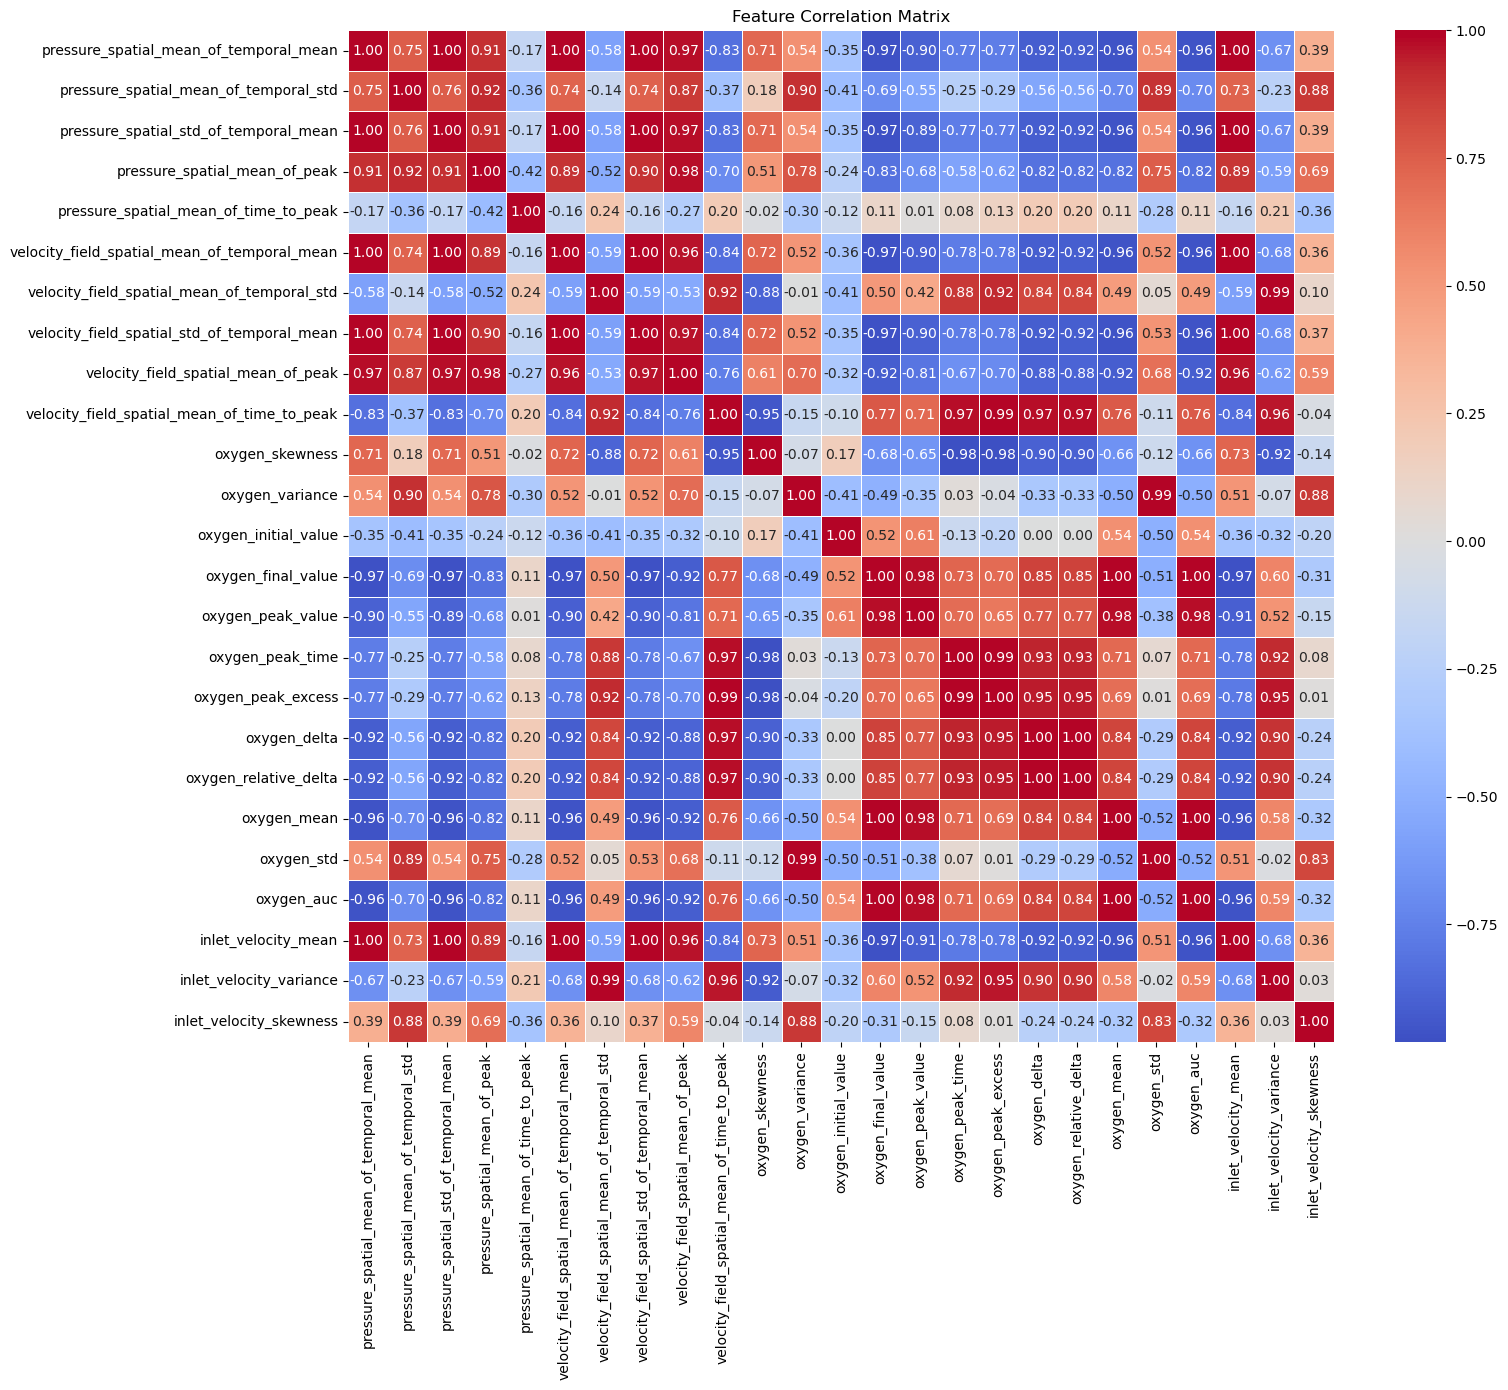


Highly correlated pairs (|r| >= 0.95):
  oxygen_delta  ↔  oxygen_relative_delta  →  r = 1.000
  oxygen_mean  ↔  oxygen_auc  →  r = 1.000
  pressure_spatial_mean_of_temporal_mean  ↔  pressure_spatial_std_of_temporal_mean  →  r = 1.000
  velocity_field_spatial_mean_of_temporal_mean  ↔  inlet_velocity_mean  →  r = 1.000
  velocity_field_spatial_mean_of_temporal_mean  ↔  velocity_field_spatial_std_of_temporal_mean  →  r = 1.000
  velocity_field_spatial_std_of_temporal_mean  ↔  inlet_velocity_mean  →  r = 1.000
  pressure_spatial_mean_of_temporal_mean  ↔  velocity_field_spatial_std_of_temporal_mean  →  r = 1.000
  oxygen_final_value  ↔  oxygen_auc  →  r = 1.000
  oxygen_final_value  ↔  oxygen_mean  →  r = 1.000
  pressure_spatial_std_of_temporal_mean  ↔  velocity_field_spatial_std_of_temporal_mean  →  r = 1.000
  pressure_spatial_mean_of_temporal_mean  ↔  velocity_field_spatial_mean_of_temporal_mean  →  r = 1.000
  pressure_spatial_std_of_temporal_mean  ↔  velocity_field_spatial_mean_of_te

In [51]:
# 1. Correlation matrix (no normalization needed)
corr = df_features.drop(columns=["cluster"], errors="ignore").corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


# Features listed in order of preference (most preferred first)
# When two features are highly correlated, the one appearing earlier here is kept
FEATURE_PRIORITY = [
    # Oxygen — simpler/more direct first
    "oxygen_delta",
    "oxygen_mean",
    "oxygen_std",
    "oxygen_auc",
    "oxygen_peak_time",
    "oxygen_peak_value",
    "oxygen_peak_excess",
    "oxygen_final_value",
    "oxygen_initial_value",
    "oxygen_relative_delta",   # redundant with oxygen_delta
    # Pressure
    "pressure_spatial_mean_of_temporal_mean",
    "pressure_spatial_mean_of_peak",
    "pressure_spatial_mean_of_time_to_peak",
    "pressure_spatial_mean_of_temporal_std",
    "pressure_spatial_std_of_temporal_mean",
    # Velocity
    "velocity_field_spatial_mean_of_temporal_mean",
    "velocity_field_spatial_mean_of_peak",
    "velocity_field_spatial_mean_of_time_to_peak",
    "velocity_field_spatial_mean_of_temporal_std",
    "velocity_field_spatial_std_of_temporal_mean",
]

def priority(feature_name):
    """Lower index = higher priority. Unknown features go to the end."""
    try:
        return FEATURE_PRIORITY.index(feature_name)
    except ValueError:
        return len(FEATURE_PRIORITY)  # unknown features get lowest priority


# 2. Identify pairs with correlation above threshold
threshold = 0.95

high_corr_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr.iloc[i, j]) >= threshold:
            high_corr_pairs.append((cols[i], cols[j], corr.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| >= {threshold}):")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a}  ↔  {b}  →  r = {r:.3f}")

# Drop features using priority ordering
to_drop = set()
for a, b, r in high_corr_pairs:
    # Keep whichever has higher priority (lower index), drop the other
    if priority(a) <= priority(b):
        if b not in to_drop:
            to_drop.add(b)
    else:
        if a not in to_drop:
            to_drop.add(a)

print(f"\nFeatures to drop: {sorted(to_drop)}")

df_features_reduced = df_features.drop(columns=list(to_drop), errors="ignore")
print(f"\nShape before: {df_features.shape}  →  after: {df_features_reduced.shape}")

In [52]:
df_features_reduced

,pressure_spatial_mean_of_temporal_std,pressure_spatial_mean_of_peak,pressure_spatial_mean_of_time_to_peak,velocity_field_spatial_mean_of_temporal_std,oxygen_initial_value,oxygen_peak_time,oxygen_delta,oxygen_mean,oxygen_std,inlet_velocity_skewness
020concentration,0.002035,0.020701,0.017351,0.001428,0.5,0.402010,0.000006,0.506644,0.011824,-3.330225
021concentration,0.008135,0.136085,0.000813,0.001358,0.5,0.180905,-0.079995,0.432423,0.025657,1.306042
022concentration,0.006311,0.108421,0.000995,0.001170,0.5,0.221106,-0.059999,0.451379,0.022121,-0.492245
023concentration,0.004535,0.080871,0.001640,0.001166,0.5,0.261307,-0.040001,0.470383,0.018705,-2.746140
024concentration,0.003148,0.053455,0.002300,0.001397,0.5,0.341709,-0.020005,0.489372,0.015624,-3.592755
025concentration,0.002640,0.020814,0.069919,0.001847,0.5,0.442211,-0.000012,0.508599,0.013579,-3.334458
026concentration,0.003236,0.026182,0.007193,0.002116,0.5,0.603015,0.019977,0.527267,0.012753,-2.580524
027concentration,0.003629,0.026181,0.008910,0.002321,0.5,0.804020,0.039952,0.545725,0.014163,-1.914695
028concentration,0.003854,0.026179,0.010349,0.002432,0.5,1.005025,0.059896,0.563580,0.017716,-1.382258
029concentration,0.003909,0.026178,0.013104,0.002438,0.5,1.346734,0.079761,0.580590,0.022804,-0.906971


### 2.3 Visualize data

#### O2 Concentration over time, with regression line

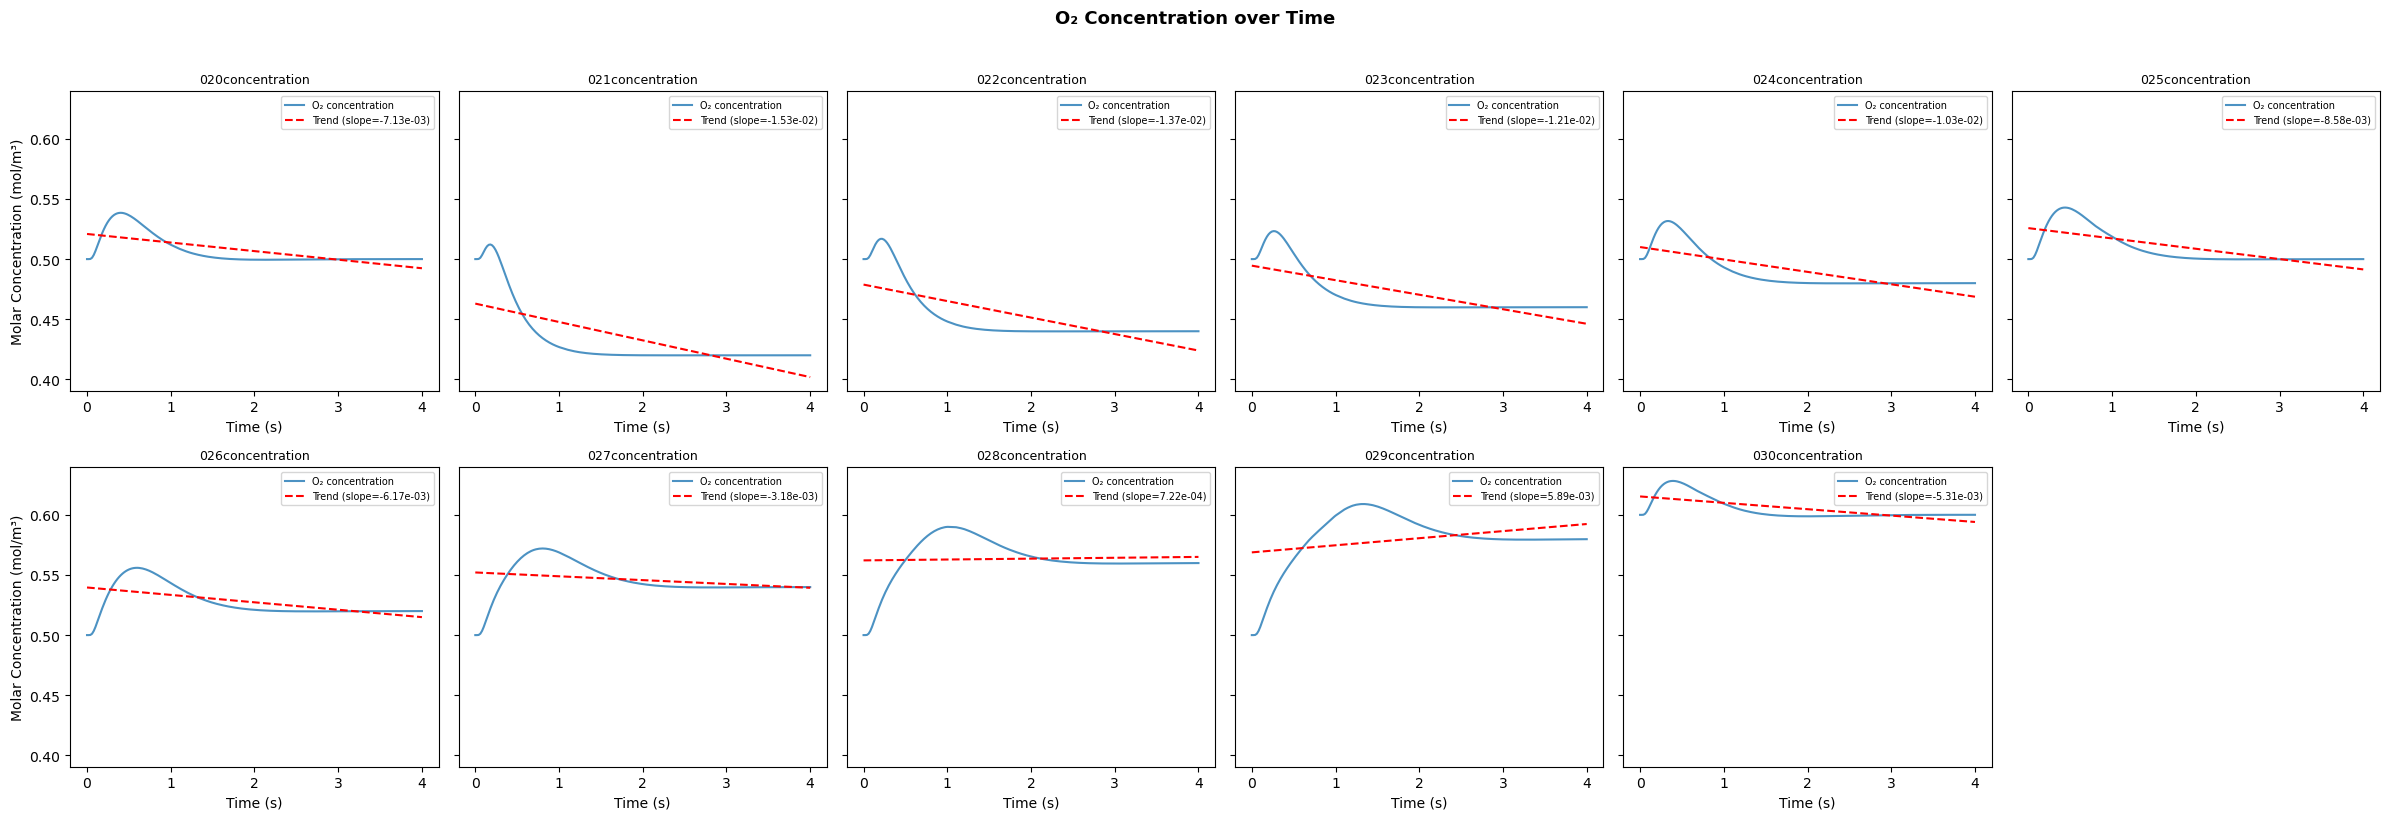

In [18]:
import math

# 1. Configuration
n_cols = 6
n_plots = len(folder_names)
n_rows = math.ceil(n_plots / n_cols)

# 2. Create the figure
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(4 * n_cols, 4 * n_rows), 
    sharey=True
)

# 3. Flatten axes for easy iteration (handles 1D and 2D cases automatically)
axes_flat = axes.flatten()

for i, folder in enumerate(folder_names):
    ax = axes_flat[i]
    key = (folder, "oxygen_concentration")
    
    if key not in dataframes:
        ax.set_title(f"{folder}\n(no O₂ data)")
        continue

    df_o2      = dataframes[key]
    time_cols  = get_data_columns(df_o2)
    timestamps = parse_timestamps(time_cols)
    values     = df_o2[time_cols].values.flatten()
    interp     = np.interp(common_times, timestamps, values)

    slope, intercept = np.polyfit(common_times, interp, 1)
    trend = slope * common_times + intercept

    ax.plot(common_times, interp, alpha=0.8, label="O₂ concentration")
    ax.plot(common_times, trend, "--", color="red",
            label=f"Trend (slope={slope:.2e})")
    ax.set_title(folder, fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=7)

    # Set Y label only for the leftmost plots
    if i % n_cols == 0:
        ax.set_ylabel("Molar Concentration (mol/m³)")

# 4. Hide unused subplots (e.g., if you have 11 plots, hide the 4 empty ones)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle("O₂ Concentration over Time", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### All O2 curves on one plot

C:\Users\icaro\AppData\Local\Temp\ipykernel_50016\2037340963.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


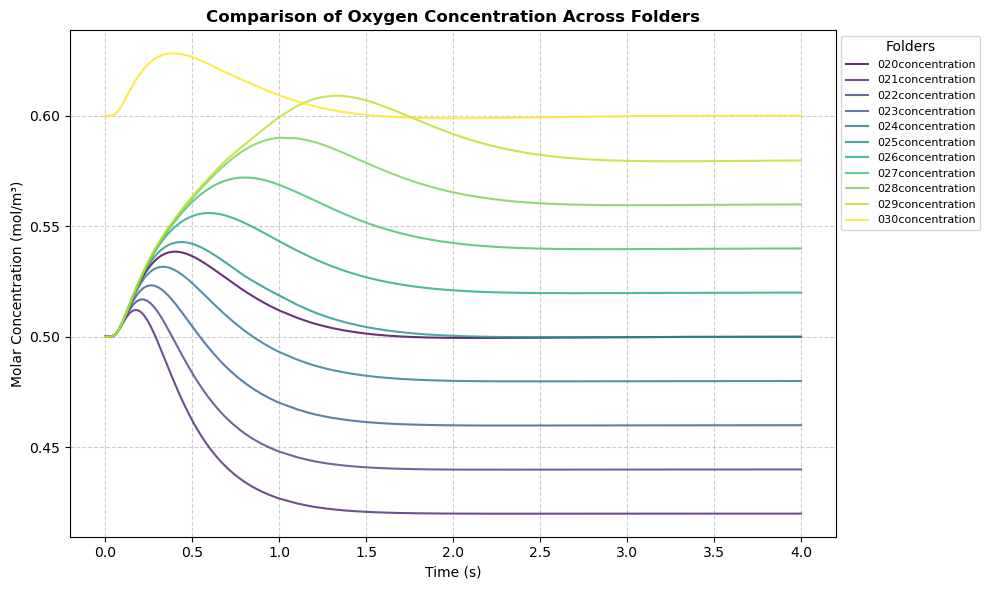

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Create a gradient colormap 
# 'viridis' is great for visibility; 'magma' or 'Blues' are also good options
cmap = plt.cm.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(folder_names)))

for i, (folder, color) in enumerate(zip(folder_names, colors)):
    key = (folder, "oxygen_concentration")
    if key not in dataframes:
        continue

    # Data processing
    df_o2      = dataframes[key]
    time_cols  = get_data_columns(df_o2)
    timestamps = parse_timestamps(time_cols)
    values     = df_o2[time_cols].values.flatten()
    interp     = np.interp(common_times, timestamps, values)

    # 2. Plotting with label for the legend
    ax.plot(common_times, interp, label=folder, color=color, linewidth=1.5, alpha=0.8)

# 3. Adding Labels and Title
ax.set_xlabel("Time (s)", fontsize=10)
ax.set_ylabel("Molar Concentration (mol/m³)", fontsize=10)
ax.set_title("Comparison of Oxygen Concentration Across Folders", fontsize=12, fontweight='bold')

# 4. Adding the Legend
# 'bbox_to_anchor' moves the legend outside if you have too many folders
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8, title="Folders")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Adjusts layout so legend isn't cut off
plt.show()

#### Bar chart of extracted features per fuel

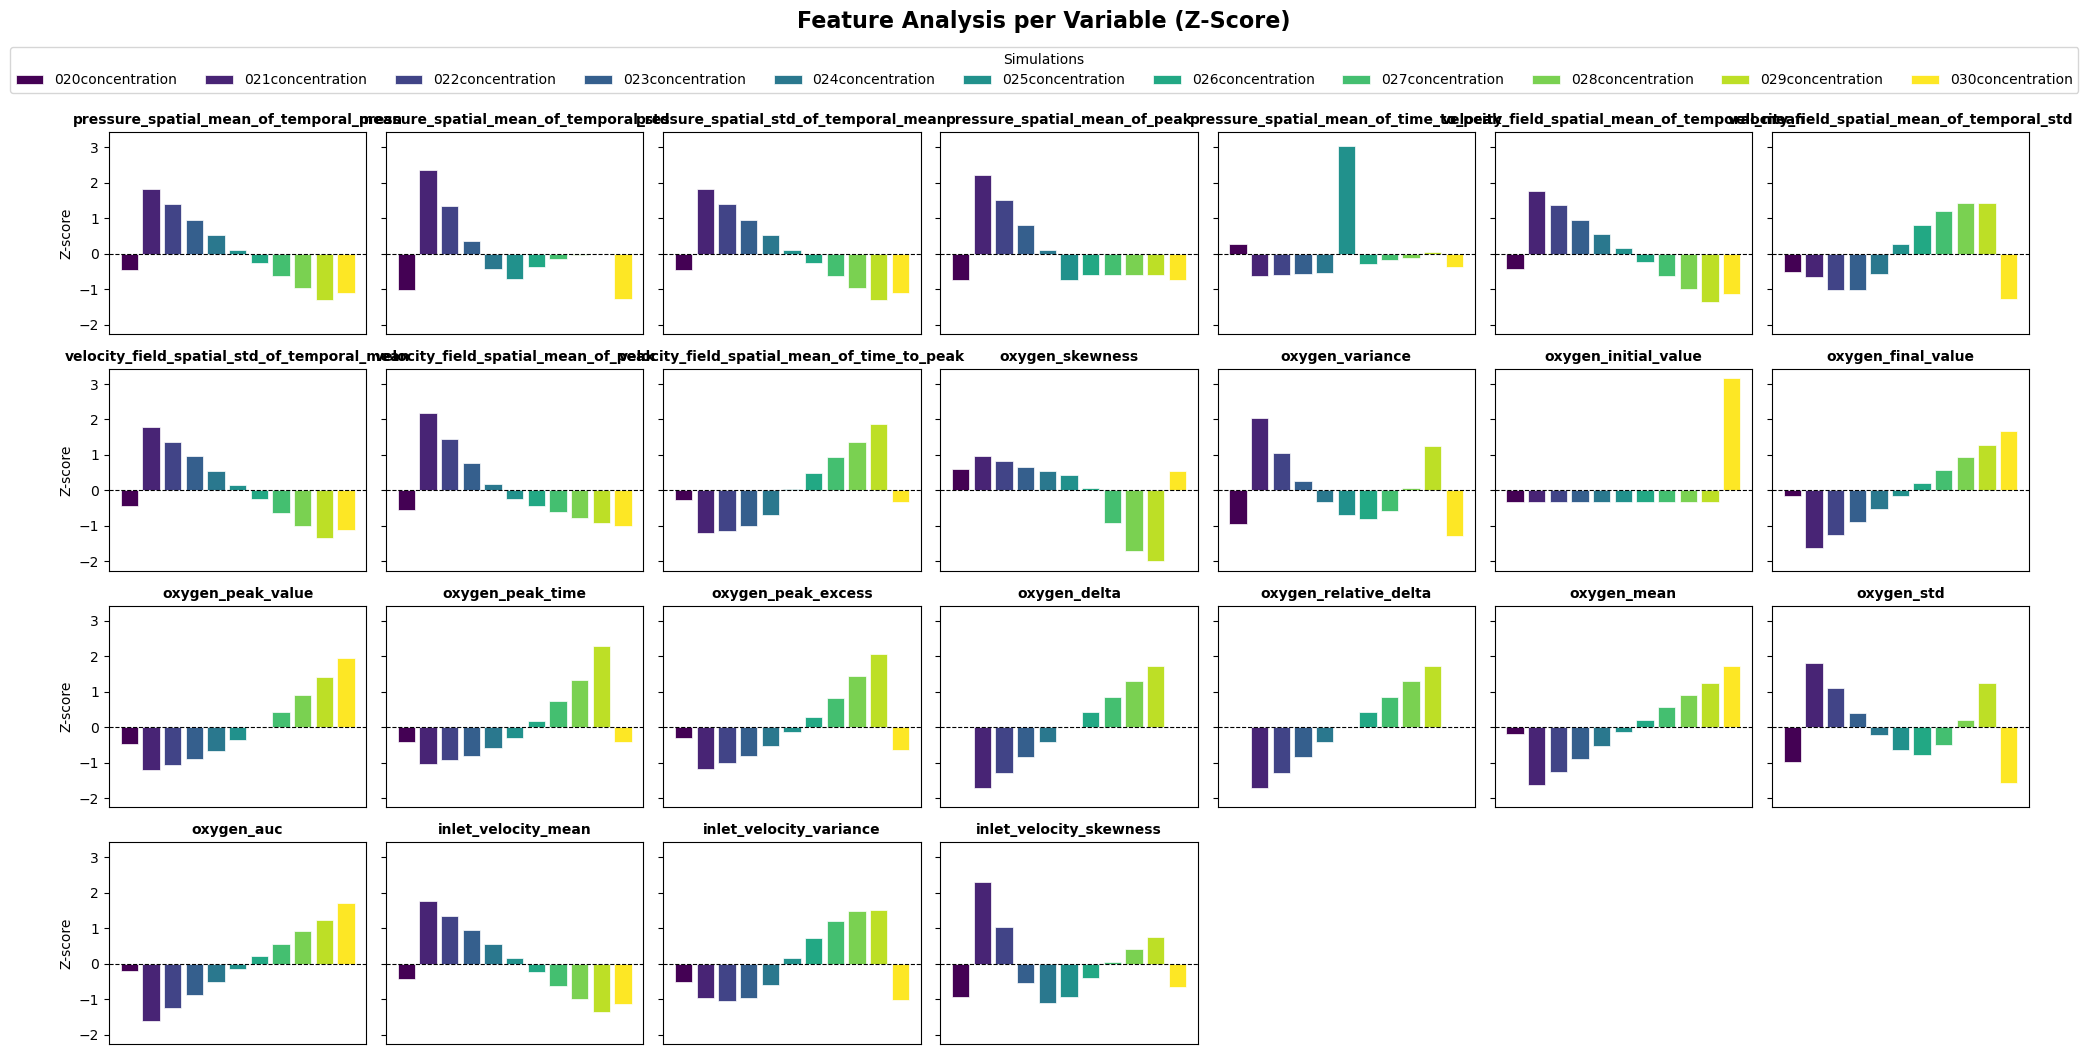

In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# 1. Filter and Normalize
df_for_viz = feature_matrix.loc[:, feature_matrix.std() > 0] 

scaler = StandardScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_for_viz),
    index=df_for_viz.index,
    columns=df_for_viz.columns
)

# 1. Configuration for the grid
n_cols = 7
n_features = len(df_normalized.columns)
n_rows = math.ceil(n_features / n_cols)

# 2. Create the figure
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(20, 10), 
    sharey=True # Usually better False for features with different scales
)

axes_flat = axes.flatten()
colors = plt.cm.viridis(np.linspace(0, 1, len(folder_names)))

# 3. Iterate through each feature (column) to create a subplot
for i, feature_name in enumerate(df_normalized.columns):
    ax = axes_flat[i]
    
    # Get the data for this specific feature across all simulations
    feature_values = df_normalized[feature_name]
    
    # Plot bars for each simulation (folder)
    # We use a simple range for x since we are comparing folders for ONE feature
    bars = ax.bar(folder_names, feature_values, color=colors, edgecolor='white', linewidth=0.5)
    
    ax.set_title(feature_name, fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    # Clean up x-axis (hide labels if there are too many, or rotate them)
    ax.set_xticks([]) # Hiding folder names on x-axis to keep it clean
    
    # Optional: Add Y-label only to the start of each row
    if i % n_cols == 0:
        ax.set_ylabel("Z-score")

# 4. Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# 5. Add a single legend for the whole figure
fig.legend(bars, folder_names, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=len(folder_names), fontsize=10, title="Simulations")

fig.suptitle("Feature Analysis per Variable (Z-Score)", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

#### Heatmap of the feature matrix

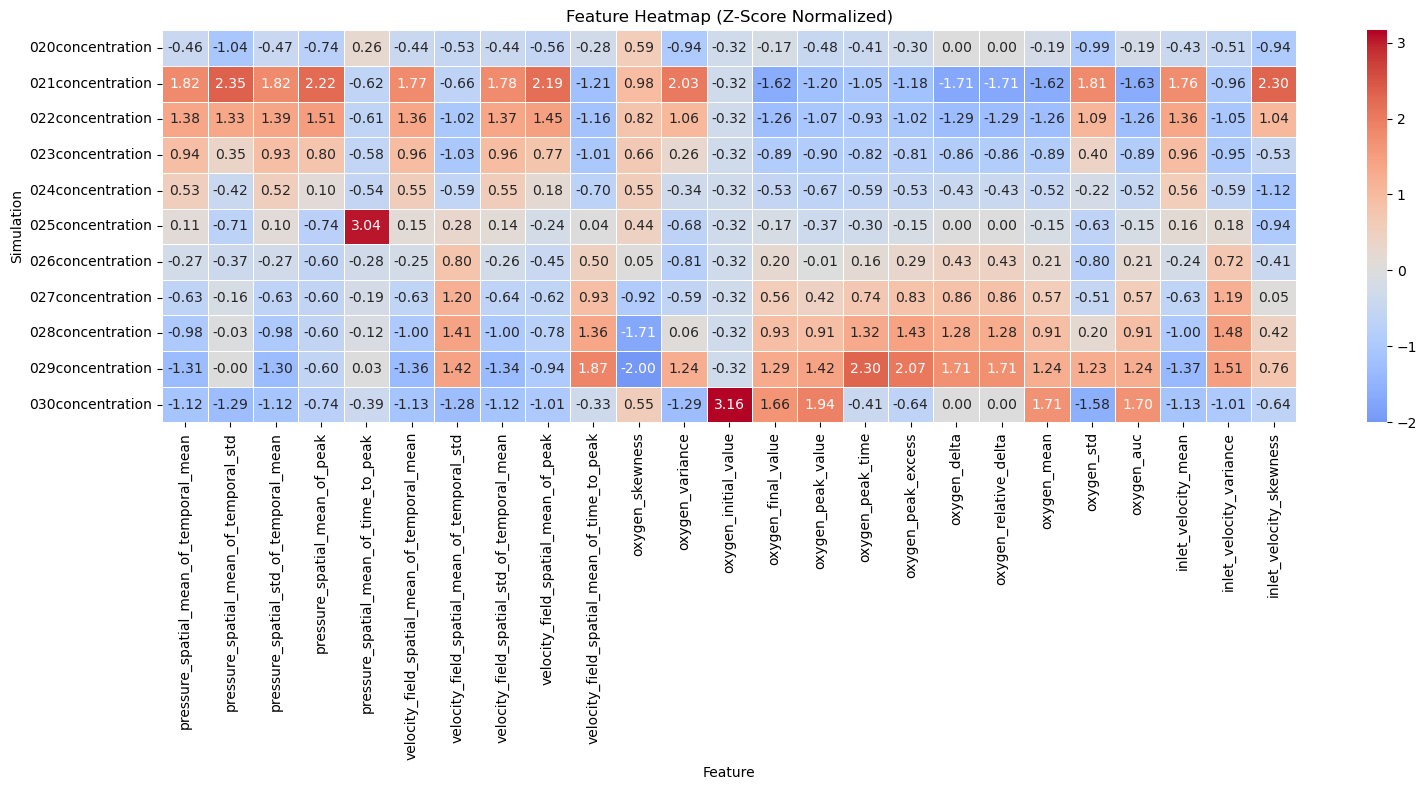

In [21]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    df_normalized,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Heatmap (Z-Score Normalized)")
ax.set_xlabel("Feature")
ax.set_ylabel("Simulation")
plt.tight_layout()
plt.show()

In [22]:
print(df_normalized.shape)
print(df_normalized)

(11, 25)
                  pressure_spatial_mean_of_temporal_mean  \
020concentration                               -0.462485   
021concentration                                1.815450   
022concentration                                1.383000   
023concentration                                0.938436   
024concentration                                0.528137   
025concentration                                0.107662   
026concentration                               -0.266537   
027concentration                               -0.631988   
028concentration                               -0.979714   
029concentration                               -1.313105   
030concentration                               -1.118857   

                  pressure_spatial_mean_of_temporal_std  \
020concentration                              -1.040677   
021concentration                               2.345715   
022concentration                               1.332971   
023concentration                  

In [23]:
df_normalized

,pressure_spatial_mean_of_temporal_mean,pressure_spatial_mean_of_temporal_std,pressure_spatial_std_of_temporal_mean,pressure_spatial_mean_of_peak,pressure_spatial_mean_of_time_to_peak,velocity_field_spatial_mean_of_temporal_mean,velocity_field_spatial_mean_of_temporal_std,velocity_field_spatial_std_of_temporal_mean,velocity_field_spatial_mean_of_peak,velocity_field_spatial_mean_of_time_to_peak,...,oxygen_peak_time,oxygen_peak_excess,oxygen_delta,oxygen_relative_delta,oxygen_mean,oxygen_std,oxygen_auc,inlet_velocity_mean,inlet_velocity_variance,inlet_velocity_skewness
020concentration,-0.462485,-1.040677,-0.467003,-0.743694,0.256068,-0.437066,-0.526613,-0.444132,-0.558548,-0.283704,...,-0.414289,-0.296024,0.000874,0.000887,-0.189157,-0.987316,-0.188923,-0.429230,-0.514249,-0.935118
021concentration,1.815450,2.345715,1.822580,2.224207,-0.620965,1.771273,-0.661193,1.782246,2.190292,-1.211819,...,-1.048832,-1.180600,-1.713860,-1.713847,-1.624680,1.806652,-1.625461,1.758210,-0.960470,2.299303
022concentration,1.383000,1.332971,1.387704,1.512615,-0.611327,1.362668,-1.024076,1.366505,1.453850,-1.158484,...,-0.933461,-1.021773,-1.285264,-1.285251,-1.258048,1.092524,-1.258548,1.358976,-1.046675,1.044756
023concentration,0.938436,0.346727,0.933363,0.803979,-0.577088,0.958449,-1.033225,0.956863,0.769727,-1.014021,...,-0.818089,-0.807135,-0.856643,-0.856630,-0.890479,0.402459,-0.890695,0.961874,-0.954224,-0.527640
024concentration,0.528137,-0.423167,0.523712,0.098793,-0.542088,0.554909,-0.586709,0.549591,0.182531,-0.702276,...,-0.587346,-0.525780,-0.428037,-0.428024,-0.523222,-0.219773,-0.523155,0.562930,-0.593946,-1.118268
025concentration,0.107662,-0.705263,0.101842,-0.740795,3.043908,0.147928,0.281638,0.140498,-0.238800,0.035027,...,-0.298917,-0.149796,0.000488,0.000501,-0.151346,-0.632870,-0.150981,0.157305,0.176642,-0.938071
026concentration,-0.266537,-0.374142,-0.270288,-0.602720,-0.282630,-0.245749,0.801687,-0.255027,-0.448472,0.498103,...,0.162569,0.289791,0.428930,0.428943,0.209727,-0.799794,0.210354,-0.239392,0.721962,-0.412100
027concentration,-0.631988,-0.155992,-0.633074,-0.602758,-0.191579,-0.629089,1.197104,-0.636281,-0.624717,0.933575,...,0.739427,0.829520,0.857064,0.857077,0.566716,-0.514956,0.567592,-0.627728,1.194916,0.052405
028concentration,-0.979714,-0.031251,-0.976927,-0.602792,-0.115238,-0.997860,1.412351,-0.997888,-0.783727,1.357645,...,1.316285,1.433435,1.284530,1.284543,0.912070,0.202792,0.913155,-1.003251,1.479095,0.423852
029concentration,-1.313105,-0.000385,-1.304577,-0.602825,0.030850,-1.355950,1.423311,-1.341445,-0.935215,1.874886,...,2.296943,2.070141,1.710312,1.710325,1.241059,1.230432,1.242304,-1.369660,1.506001,0.755429


## 3. Machine Learning

### 3.1 Import libraries

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### 3.2 Normalize data

In [55]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    index=df_features.index,
    columns=df_features.columns
)

X_scaled_reduced = pd.DataFrame(
    scaler.fit_transform(df_features_reduced),
    index=df_features_reduced.index,
    columns=df_features_reduced.columns
)

In [56]:
X_scaled

,pressure_spatial_mean_of_temporal_mean,pressure_spatial_mean_of_temporal_std,pressure_spatial_std_of_temporal_mean,pressure_spatial_mean_of_peak,pressure_spatial_mean_of_time_to_peak,velocity_field_spatial_mean_of_temporal_mean,velocity_field_spatial_mean_of_temporal_std,velocity_field_spatial_std_of_temporal_mean,velocity_field_spatial_mean_of_peak,velocity_field_spatial_mean_of_time_to_peak,...,oxygen_peak_time,oxygen_peak_excess,oxygen_delta,oxygen_relative_delta,oxygen_mean,oxygen_std,oxygen_auc,inlet_velocity_mean,inlet_velocity_variance,inlet_velocity_skewness
020concentration,-0.462485,-1.040677,-0.467003,-0.743694,0.256068,-0.437066,-0.526613,-0.444132,-0.558548,-0.283704,...,-0.414289,-0.296024,0.000874,0.000887,-0.189157,-0.987316,-0.188923,-0.429230,-0.514249,-0.935118
021concentration,1.815450,2.345715,1.822580,2.224207,-0.620965,1.771273,-0.661193,1.782246,2.190292,-1.211819,...,-1.048832,-1.180600,-1.713860,-1.713847,-1.624680,1.806652,-1.625461,1.758210,-0.960470,2.299303
022concentration,1.383000,1.332971,1.387704,1.512615,-0.611327,1.362668,-1.024076,1.366505,1.453850,-1.158484,...,-0.933461,-1.021773,-1.285264,-1.285251,-1.258048,1.092524,-1.258548,1.358976,-1.046675,1.044756
023concentration,0.938436,0.346727,0.933363,0.803979,-0.577088,0.958449,-1.033225,0.956863,0.769727,-1.014021,...,-0.818089,-0.807135,-0.856643,-0.856630,-0.890479,0.402459,-0.890695,0.961874,-0.954224,-0.527640
024concentration,0.528137,-0.423167,0.523712,0.098793,-0.542088,0.554909,-0.586709,0.549591,0.182531,-0.702276,...,-0.587346,-0.525780,-0.428037,-0.428024,-0.523222,-0.219773,-0.523155,0.562930,-0.593946,-1.118268
025concentration,0.107662,-0.705263,0.101842,-0.740795,3.043908,0.147928,0.281638,0.140498,-0.238800,0.035027,...,-0.298917,-0.149796,0.000488,0.000501,-0.151346,-0.632870,-0.150981,0.157305,0.176642,-0.938071
026concentration,-0.266537,-0.374142,-0.270288,-0.602720,-0.282630,-0.245749,0.801687,-0.255027,-0.448472,0.498103,...,0.162569,0.289791,0.428930,0.428943,0.209727,-0.799794,0.210354,-0.239392,0.721962,-0.412100
027concentration,-0.631988,-0.155992,-0.633074,-0.602758,-0.191579,-0.629089,1.197104,-0.636281,-0.624717,0.933575,...,0.739427,0.829520,0.857064,0.857077,0.566716,-0.514956,0.567592,-0.627728,1.194916,0.052405
028concentration,-0.979714,-0.031251,-0.976927,-0.602792,-0.115238,-0.997860,1.412351,-0.997888,-0.783727,1.357645,...,1.316285,1.433435,1.284530,1.284543,0.912070,0.202792,0.913155,-1.003251,1.479095,0.423852
029concentration,-1.313105,-0.000385,-1.304577,-0.602825,0.030850,-1.355950,1.423311,-1.341445,-0.935215,1.874886,...,2.296943,2.070141,1.710312,1.710325,1.241059,1.230432,1.242304,-1.369660,1.506001,0.755429


In [57]:
X_scaled_reduced

,pressure_spatial_mean_of_temporal_std,pressure_spatial_mean_of_peak,pressure_spatial_mean_of_time_to_peak,velocity_field_spatial_mean_of_temporal_std,oxygen_initial_value,oxygen_peak_time,oxygen_delta,oxygen_mean,oxygen_std,inlet_velocity_skewness
020concentration,-1.040677,-0.743694,0.256068,-0.526613,-0.316228,-0.414289,0.000874,-0.189157,-0.987316,-0.935118
021concentration,2.345715,2.224207,-0.620965,-0.661193,-0.316228,-1.048832,-1.713860,-1.624680,1.806652,2.299303
022concentration,1.332971,1.512615,-0.611327,-1.024076,-0.316228,-0.933461,-1.285264,-1.258048,1.092524,1.044756
023concentration,0.346727,0.803979,-0.577088,-1.033225,-0.316228,-0.818089,-0.856643,-0.890479,0.402459,-0.527640
024concentration,-0.423167,0.098793,-0.542088,-0.586709,-0.316228,-0.587346,-0.428037,-0.523222,-0.219773,-1.118268
025concentration,-0.705263,-0.740795,3.043908,0.281638,-0.316228,-0.298917,0.000488,-0.151346,-0.632870,-0.938071
026concentration,-0.374142,-0.602720,-0.282630,0.801687,-0.316228,0.162569,0.428930,0.209727,-0.799794,-0.412100
027concentration,-0.155992,-0.602758,-0.191579,1.197104,-0.316228,0.739427,0.857064,0.566716,-0.514956,0.052405
028concentration,-0.031251,-0.602792,-0.115238,1.412351,-0.316228,1.316285,1.284530,0.912070,0.202792,0.423852
029concentration,-0.000385,-0.602825,0.030850,1.423311,-0.316228,2.296943,1.710312,1.241059,1.230432,0.755429


## 4. K-means

### 4.1 K-Means initial run

In [59]:
# With only 3 simulations, use k=3 (one cluster per fuel is the hypothesis)
kmeans = KMeans(n_clusters=11, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled_reduced)

df_features["cluster"] = labels
print(df_features["cluster"])

020concentration     7
021concentration     2
022concentration     6
023concentration     9
024concentration     0
025concentration     4
026concentration     5
027concentration    10
028concentration     1
029concentration     8
030concentration     3
Name: cluster, dtype: int32


c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


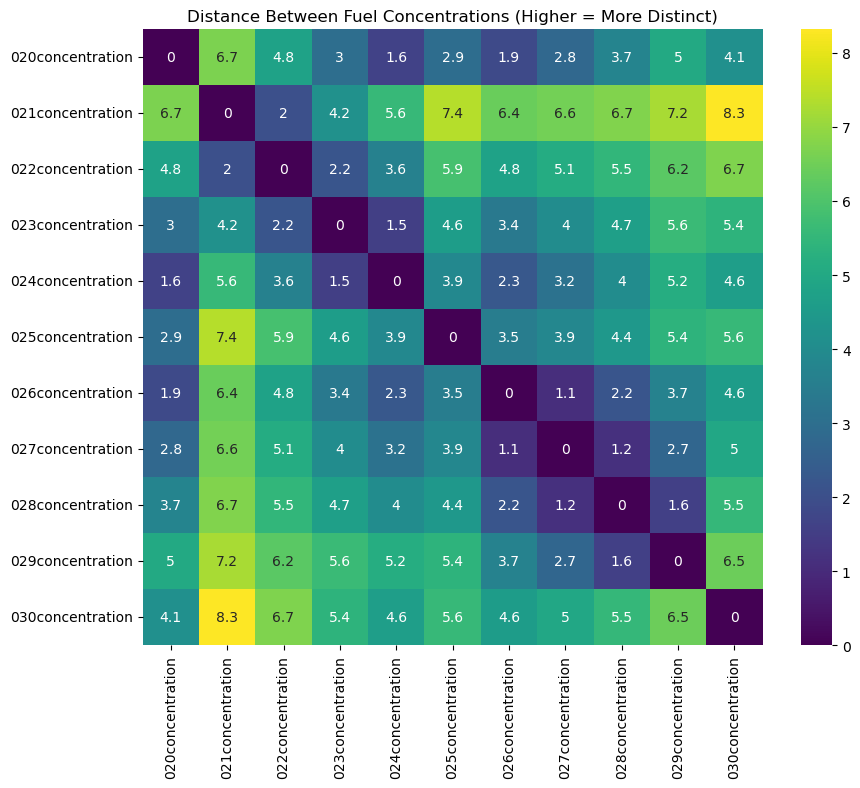

In [60]:
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

# Calculate how different each fuel is from the others
dist_matrix = euclidean_distances(X_scaled_reduced)

plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, annot=True, xticklabels=folder_names, yticklabels=folder_names, cmap='viridis')
plt.title("Distance Between Fuel Concentrations (Higher = More Distinct)")
plt.show()

### 4.2 Elbow Method and Silhouette Analysis - Select best k

**The Elbow Method**

In aerospace and combustion chemistry, different concentrations often behave similarly until they hit a "tipping point" or a phase change.

This is the standard way to find the "optimal" $k$. It calculates the Inertia (the sum of squared distances of samples to their closest cluster center). As you increase $k$, inertia drops. You are looking for the "elbow"—the point where adding more clusters no longer significantly improves the fit.

c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-pa

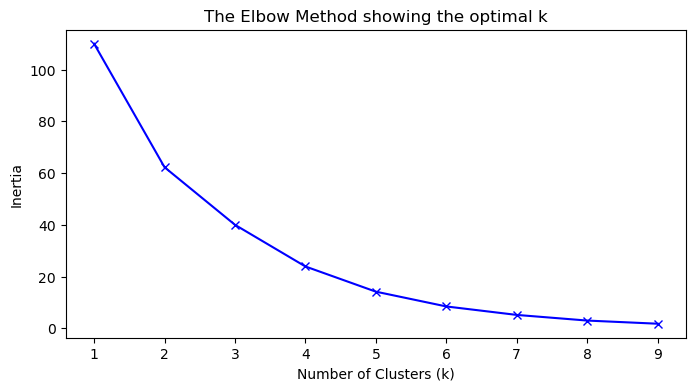

In [58]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10) # Testing 1 through 9 clusters

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_reduced)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

**The Silhouette Analysis**

Since your previous error occurred because $k$ was too high relative to your samples, try testing $k$ from 2 to 6. This measures how well-separated the groups are. The highest peak is your "True" number of fuel types.

c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-pa

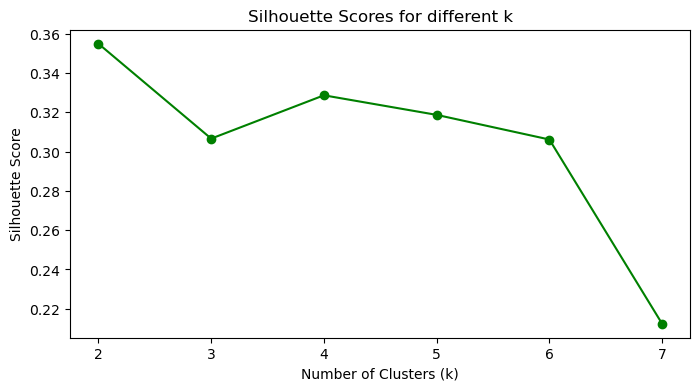

In [61]:
from sklearn.metrics import silhouette_score

sil_scores = []
# Only test up to n_samples - 1
for k in range(2, 8): 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_reduced)
    sil_scores.append(silhouette_score(X_scaled_reduced, labels))

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), sil_scores, 'go-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for different k')
plt.show()

**Elbow plot**

There's no sharp elbow, which confirms the gradient structure we discussed. The curve decreases smoothly, meaning no value of k is dramatically better than the others. If forced to pick, k=2 or k=3 is where the curve starts flattening most noticeably.

**Silhouette plot**

This is the more informative one here. The highest score is at k=2 (≈0.40), which is your statistically best-supported clustering. The small local peak at k=4 (≈0.365) is interesting though — it suggests that if you want more granularity, 4 groups is the next most coherent option compared to 3 or 5.


**Interpretation**

Both plots are consistent with the DBSCAN results — your data genuinely prefers being split into 2 broad groups rather than finer subdivisions. Physically this could mean there's a threshold somewhere around the middle of your concentration range where combustion behavior shifts regime, with the simulations on either side behaving more similarly to each other than across the threshold.

For your report I'd suggest running K-Means with both k=2 and k=4 and showing the PCA scatter plot for each, so you can discuss both the "coarse" and "fine" grouping. The k=4 result is worth exploring because it might reveal something physically meaningful about intermediate concentrations — and it's more interesting to present than just two blobs.

### 4.3 Visualize with PCA

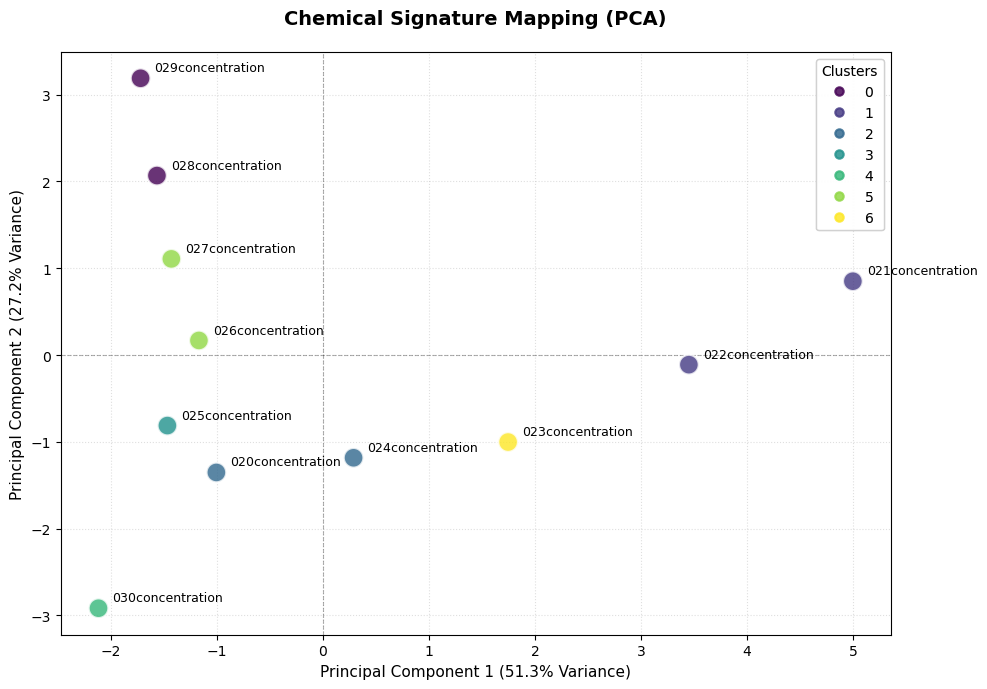

In [63]:
from sklearn.decomposition import PCA

# 1. Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_reduced)

plt.figure(figsize=(10, 7))

# 2. Plot with Viridis and larger, distinct points
# We use 'c=labels' to color by the clusters found in your K-means step
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], 
    c=labels, 
    cmap="viridis", 
    s=200,          # Larger points for better visibility
    edgecolor='w',  # White edge makes points pop
    linewidth=1.5,
    alpha=0.8,
    zorder=3
)

# 3. Add names with improved positioning
for i, name in enumerate(df_features_reduced.index):
    plt.annotate(
        name, 
        (X_pca[i, 0], X_pca[i, 1]), 
        textcoords="offset points", 
        xytext=(10, 5), 
        fontsize=9,
        fontweight='medium'
    )

# 4. Axes and Labels (using percentage of variance)
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f"Principal Component 1 ({pc1_var:.1f}% Variance)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({pc2_var:.1f}% Variance)", fontsize=11)

# 5. Professional Aesthetics
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
plt.grid(True, linestyle=':', alpha=0.4, zorder=0)

plt.title("Chemical Signature Mapping (PCA)", fontsize=14, fontweight="bold", pad=20)

# 6. Discrete Legend instead of Colorbar
# This makes it clear which color belongs to which cluster index
legend1 = plt.legend(*scatter.legend_elements(), loc="upper right", title="Clusters")
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.savefig("figs/pca_combustion_mapping.png", dpi=300) # Increased DPI for reports
plt.show()

### 4.4 Run K-means for k = 2 and k = 4, visualize with PCA

c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


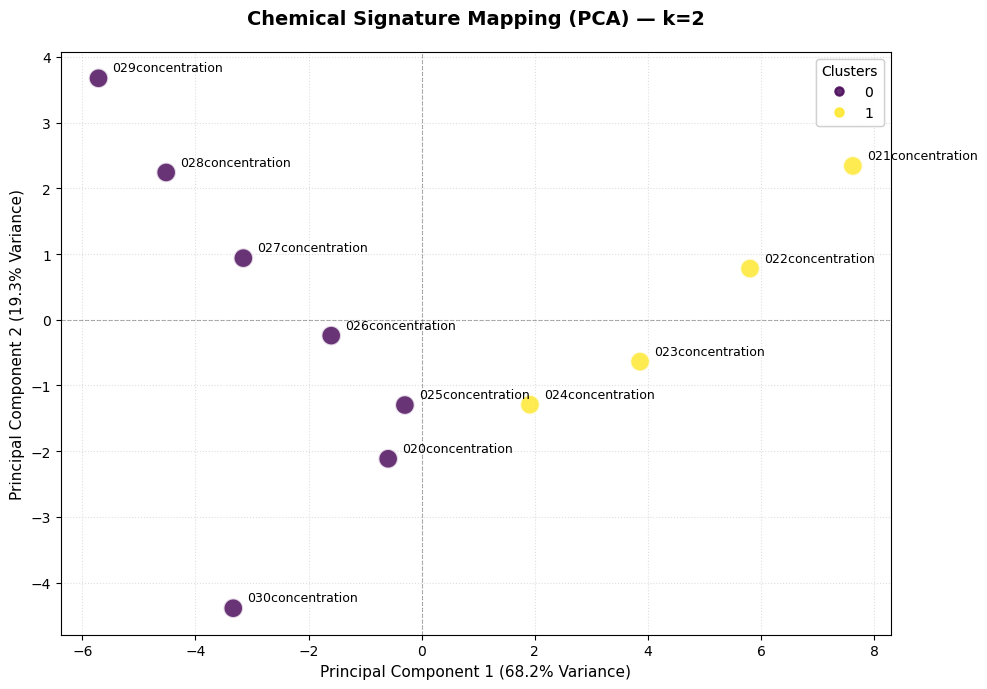

c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


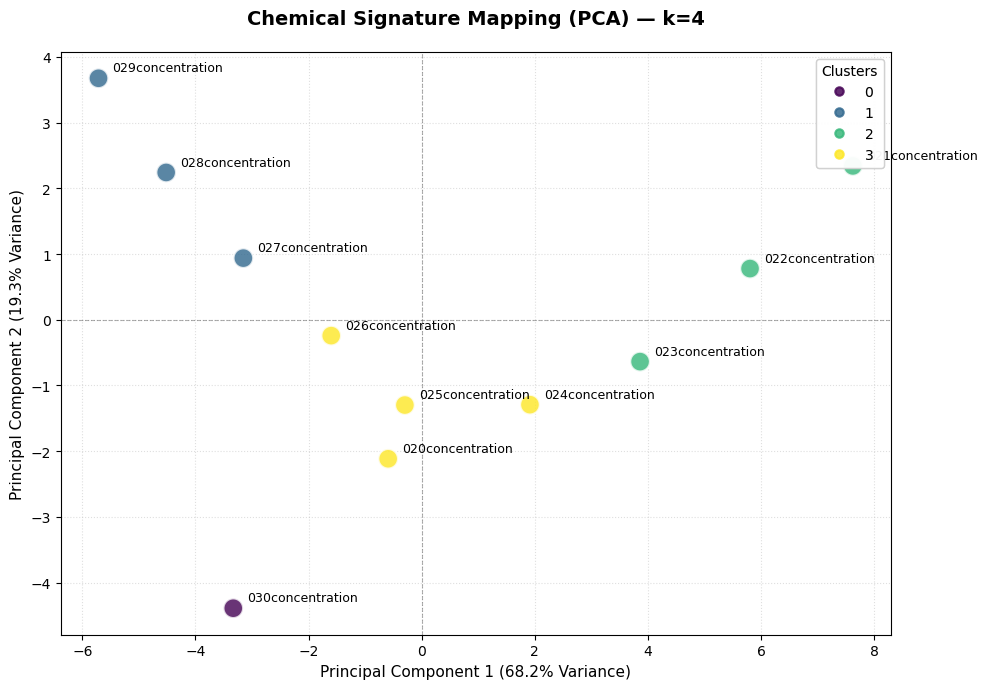

In [ ]:
for k in [2, 4]:
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_reduced)
    df_features_reduced["cluster"] = labels

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled_reduced)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=200,
        edgecolor='w',
        linewidth=1.5,
        alpha=0.8,
        zorder=3
    )

    for i, name in enumerate(df_features_reduced.index):
        plt.annotate(
            name,
            (X_pca[i, 0], X_pca[i, 1]),
            textcoords="offset points",
            xytext=(10, 5),
            fontsize=9,
            fontweight='medium'
        )

    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100
    plt.xlabel(f"Principal Component 1 ({pc1_var:.1f}% Variance)", fontsize=11)
    plt.ylabel(f"Principal Component 2 ({pc2_var:.1f}% Variance)", fontsize=11)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
    plt.grid(True, linestyle=':', alpha=0.4, zorder=0)

    plt.title(f"Chemical Signature Mapping (PCA) — k={k}", fontsize=14, fontweight="bold", pad=20)

    legend1 = plt.legend(*scatter.legend_elements(), loc="upper right", title="Clusters")
    plt.gca().add_artist(legend1)

    plt.tight_layout()
    plt.savefig(f"figs/pca_combustion_mapping_k{k}.png", dpi=300)
    plt.show()

## 5. DBSCAN

### 5.1 Find optimal k

**Why DBSCAN is tricky here**

DBSCAN has two hyperparameters — eps (neighborhood radius) and min_samples (minimum points to form a core point) — and is very sensitive to both, especially with small datasets. With 11 samples, min_samples should be kept low (2 or 3), and eps needs to be tuned carefully.
The standard way to find a good eps is the k-distance plot:

We're looking for the elbow in the curve - the point where the distance starts increasing sharply. That value on the y-axis is your eps.

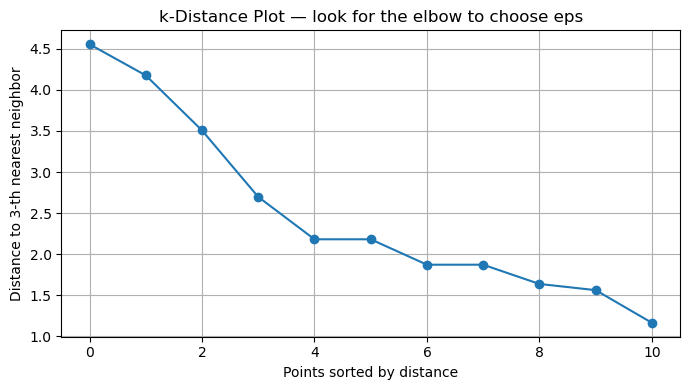

In [64]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# k-distance plot to find optimal eps
# with 11 samples, use min_samples=2 or 3
min_samples = 3
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled_reduced)
distances, _ = nbrs.kneighbors(X_scaled_reduced)
k_distances = np.sort(distances[:, -1])[::-1]  # distance to k-th neighbor, sorted descending

plt.figure(figsize=(7, 4))
plt.plot(k_distances, marker="o")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.title("k-Distance Plot — look for the elbow to choose eps")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/kdistance_plot.png", dpi=150)
plt.show()

In [65]:
# Running DBScan

eps_value = 3 # replace with value read from the elbow

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled_reduced)

print("Cluster labels:", labels)
print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Noise points (-1): {list(labels).count(-1)}")

Cluster labels: [ 0  0  0  0  0  0  0  0  0  0 -1]
Number of clusters: 1
Noise points (-1): 1


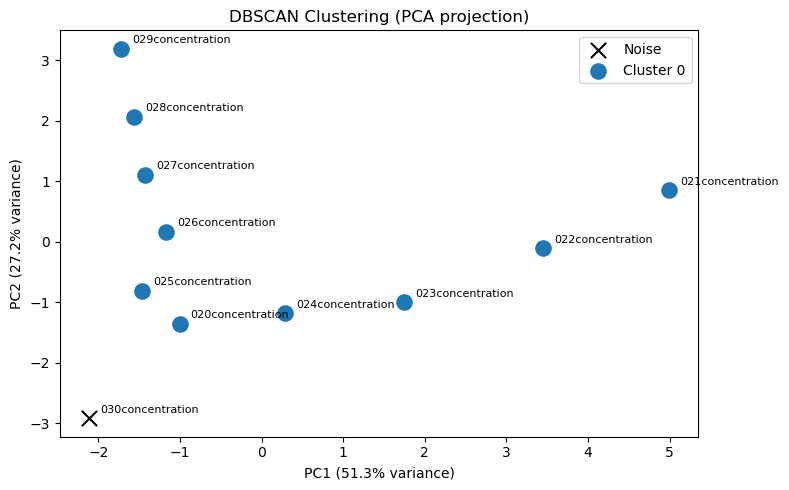

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_reduced)

fig, ax = plt.subplots(figsize=(8, 5))

unique_labels = sorted(set(labels))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels == label
    color = "black" if label == -1 else cmap(label / max(unique_labels + [1]))
    marker = "x" if label == -1 else "o"
    name = "Noise" if label == -1 else f"Cluster {label}"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], marker=marker, s=120, label=name, zorder=3)

# Annotate each point with its simulation name
for i, sim_name in enumerate(df_features_reduced.index):
    ax.annotate(sim_name, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("DBSCAN Clustering (PCA projection)")
ax.legend()
plt.tight_layout()
plt.savefig("figs/dbscan_clusters.png", dpi=150)
plt.show()

### 5.2 PCA to reduce number of components

**One thing to keep in mind**

With 11 samples and 25 features you're in a high-dimensional, low-sample regime, which is tough for any clustering algorithm. DBSCAN in particular suffers from the curse of dimensionality — distances become less meaningful as dimensions grow. It may be worth running PCA first to reduce to, say, 5–8 components before feeding into DBSCAN:

In [67]:
pca_pre = PCA(n_components=4, random_state=42)
X_reduced = pca_pre.fit_transform(X_scaled)
print(f"Variance explained: {pca_pre.explained_variance_ratio_.sum()*100:.1f}%")

# Then use X_reduced instead of X_scaled in DBSCAN and the k-distance plot

Variance explained: 98.3%


In [68]:
X_reduced

array([[-0.59237613, -2.11596085, -1.11310548, -0.55869872],
       [ 7.62259787,  2.34163225,  1.27987952,  0.6606638 ],
       [ 5.80473771,  0.77910152,  0.64303881,  0.01932485],
       [ 3.86074339, -0.63731789, -0.16639393, -0.63757486],
       [ 1.91402501, -1.29261483, -0.72521337, -1.00056011],
       [-0.29693064, -1.2983856 , -2.65919865,  2.01207414],
       [-1.59916921, -0.24164633, -0.86429652, -0.76979889],
       [-3.15253171,  0.93815037, -0.4646122 , -0.52794298],
       [-4.51697736,  2.24229865,  0.11678359, -0.1763157 ],
       [-5.71346995,  3.67585382,  0.86455314,  0.39311772],
       [-3.33064899, -4.39111111,  3.0885651 ,  0.58571074]])

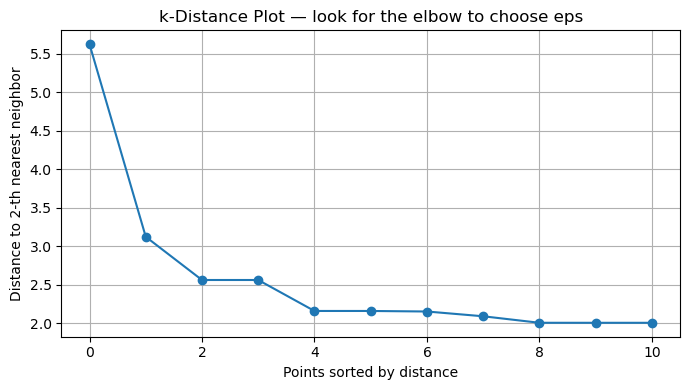

In [69]:
# k-distance plot to find optimal eps
# with 11 samples, use min_samples=2 or 3
min_samples = 2
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_reduced)
distances, _ = nbrs.kneighbors(X_reduced)
k_distances = np.sort(distances[:, -1])[::-1]  # distance to k-th neighbor, sorted descending

plt.figure(figsize=(7, 4))
plt.plot(k_distances, marker="o")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.title("k-Distance Plot — look for the elbow to choose eps")
plt.grid(True)
plt.tight_layout()
plt.savefig("figs/kdistance_plot.png", dpi=150)
plt.show()

In [70]:
# Running DBScan with X_reduced dataset

eps_value = 3 # replace with value read from the elbow

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = dbscan.fit_predict(X_reduced)

print("Cluster labels:", labels)
print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Noise points (-1): {list(labels).count(-1)}")

Cluster labels: [ 0  0  0  0  0 -1  0  0  0  0 -1]
Number of clusters: 1
Noise points (-1): 2


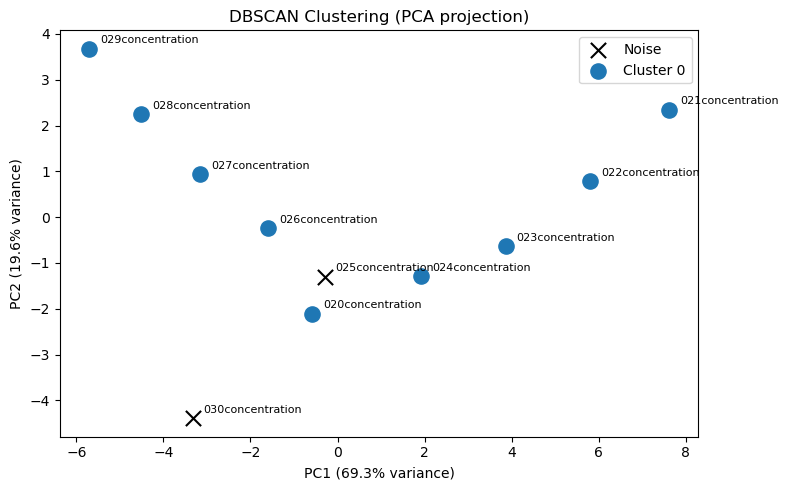

In [71]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

fig, ax = plt.subplots(figsize=(8, 5))

unique_labels = sorted(set(labels))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels == label
    color = "black" if label == -1 else cmap(label / max(unique_labels + [1]))
    marker = "x" if label == -1 else "o"
    name = "Noise" if label == -1 else f"Cluster {label}"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], marker=marker, s=120, label=name, zorder=3)

# Annotate each point with its simulation name
for i, sim_name in enumerate(df_features.index):
    ax.annotate(sim_name, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("DBSCAN Clustering (PCA projection)")
ax.legend()
plt.tight_layout()
plt.savefig("figs/dbscan_clusters.png", dpi=150)
plt.show()

**Why you're getting so few clusters**

Looking at your scaled dataset, there's a pretty clear gradient structure in the data — the feature values change smoothly and monotonically as you go from 020concentration to 030concentration. For example, pressure_spatial_mean_of_temporal_mean goes from -1.31 to +1.81 almost linearly. This means your data likely forms one continuous line in feature space, not distinct blobs — and DBSCAN (which looks for density blobs) will either call it one big cluster or start labeling the extremes as noise.
This is actually a fundamental mismatch between your data structure and DBSCAN's assumptions:

DBSCAN assumes: clusters are dense regions separated by sparse regions
Your data looks like: a smooth continuum along a concentration gradient

What this tells you physically
The fact that the data forms a gradient rather than distinct groups might itself be a meaningful result — it suggests that combustion behavior changes continuously with oxygen concentration, with no sharp phase transition or qualitative regime change between fuel types. That's a valid scientific finding worth mentioning in your report.
What to try instead
Given the gradient structure, a few alternatives are worth exploring:

## 6. PCA

### 6.1 Fit PCA and inspect explained variance
This tells how much information is captured by each component, and how many PCs are needed to retain most of the variance.

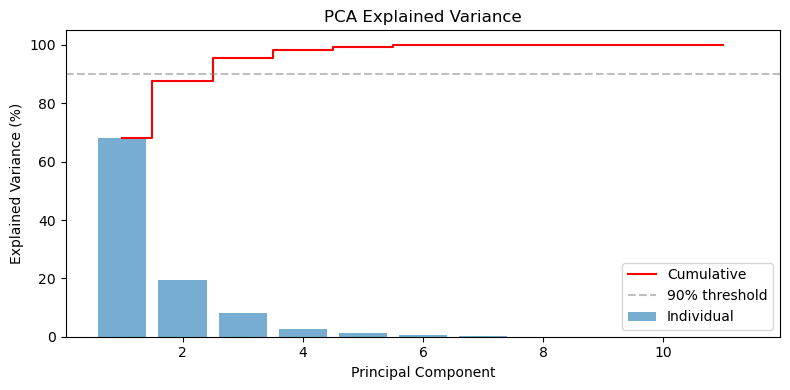

Variance explained by PC1 and PC2: 87.5%


In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
pca.fit(X_scaled)

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_ * 100, alpha=0.6, label="Individual")
plt.step(range(1, len(cumvar) + 1), cumvar, where="mid", color="red", label="Cumulative")
plt.axhline(90, color="gray", linestyle="--", alpha=0.5, label="90% threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("figs/pca_variance.png", dpi=300)
plt.show()

print("Variance explained by PC1 and PC2: "
      f"{pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

### 6.2 The main PCA plot (PC1 vs PC2)
Note the colorbar is now colored by concentration order rather than by a cluster label — this is intentional. You're letting the reader see whether the gradient in color matches the spatial arrangement of points, without imposing any grouping.

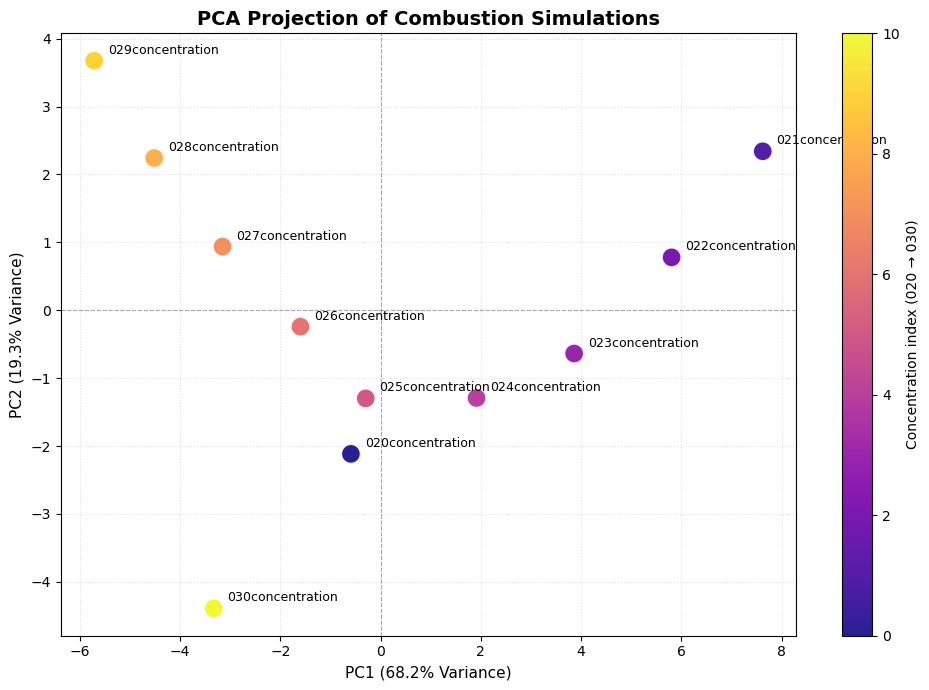

In [42]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=range(len(df_features.index)),  # color by concentration order
    cmap="plasma",
    s=200, edgecolor='w', linewidth=1.5, alpha=0.9, zorder=3
)

for i, name in enumerate(df_features.index):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC1 ({pc1_var:.1f}% Variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% Variance)", fontsize=11)
ax.set_title("PCA Projection of Combustion Simulations", fontsize=14, fontweight="bold")

plt.colorbar(scatter, ax=ax, label="Concentration index (020 → 030)")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig("figs/pca_standalone.png", dpi=300)
plt.show()

### 6.3 Biplot

A biplot overlays the original feature vectors onto the PCA projection, showing which features are driving each principal component — very useful for physical interpretation.

The arrows point in the direction of increasing feature value — features pointing in the same direction are correlated, and the simulations that lie in the direction an arrow points have high values for that feature.

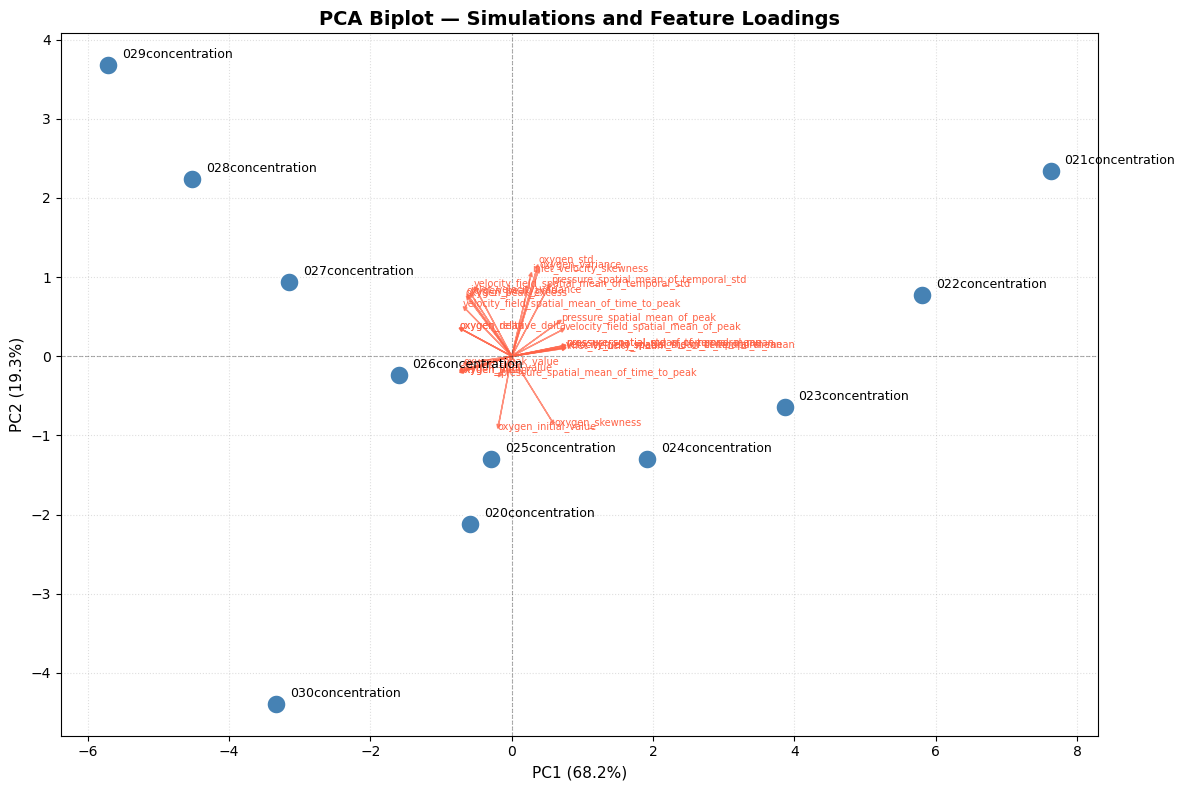

In [43]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
loadings = pca_2d.components_.T  # shape: (n_features, 2)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], s=200, edgecolor='w',
           linewidth=1.5, zorder=3, color="steelblue")

for i, name in enumerate(df_features.drop(columns=["cluster"], errors="ignore").columns):
    ax.arrow(0, 0, loadings[i, 0] * 3, loadings[i, 1] * 3,
             head_width=0.05, head_length=0.05, fc='tomato', ec='tomato', alpha=0.7)
    ax.text(loadings[i, 0] * 3.2, loadings[i, 1] * 3.2,
            name, fontsize=7, color='tomato')

for i, name in enumerate(df_features.index):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("PCA Biplot — Simulations and Feature Loadings", fontsize=14, fontweight="bold")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig("figs/pca_biplot.png", dpi=300)
plt.show()